# Capstone Project Competition - Function 1: Searching for Contamination Sources

## Initial Codebase

The problem "Function 1: Searching for Contamination Sources" is a challenging 2D optimization task focused on locating radiation sources in a square area. The objective is to find both modes (peaks) of an unknown function, which correspond to the strongest contamination locations. A key challenge is that the function's output is mostly zero unless very close to a contamination source. The problem explicitly states that the function is based on the Easom function, defined as the sum of two Easom functions, leading to two local maxima (modes).

The initial codebase adopted for this task was a **Bayesian Optimization (BO) framework** implemented in Python. This choice was driven by BO's suitability for optimizing computationally expensive, black-box functions where direct gradient information is unavailable. The framework leverages:
* `numpy` for numerical operations.
* `scipy.stats.norm` for statistical functions essential in acquisition functions.
* `sklearn.gaussian_process.GaussianProcessRegressor` for building the Gaussian Process (GP) surrogate model.
* `sklearn.gaussian_process.kernels.RBF` and `ConstantKernel as C` for defining the kernel of the Gaussian Process. (Note: Initial plan included `Matern` but pivoted to RBF due to practical issues, as seen in later code segments.)
* `skopt.dummy_minimize` for optimizing the acquisition function.
* `skopt.space.Real` for defining search bounds.

The rationale for choosing this BO framework as a starting point was its explicit recommendation for Function 1 and its established effectiveness in optimizing expensive black-box functions. The GP model helps approximate the unknown function and provides uncertainty estimates, crucial for guiding intelligent exploration. Given that the Easom function is known for sharp peaks and a relatively flat landscape, BO's ability to handle uncertainty and adapt its search is vital.

The initial data provided for Function 1 included 10 input-output pairs. Most initial outputs were extremely close to zero, but one notable non-zero negative output was observed at `[0.65011406 0.68152635]` with output `-3.60606264e-003`. This early observation guided the initial search strategy towards exploiting this promising region.

## Code Modification

As the competition progressed, I made several adjustments to the codebase. These modifications were driven by analysis of query results, principles of Bayesian Optimization, and insights from broader machine learning practices.

1.  **Initial Query Strategy Refinement (Week 1-2)**
    * **Reasoning:** While a simple `[0.5, 0.5]` query was initially considered for global exploration, analysis of the provided initial data revealed a non-zero output at `[0.65011406 0.68152635]`. This indicated a promising region for a contamination source, suggesting exploitation over blind exploration.
    * **Modification:** The strategy shifted to exploring around this non-zero region. Although an example `[0.62, 0.69]` was suggested, the BO framework would naturally guide this.
    * **Impact on Score:** By focusing on areas with initial non-zero outputs, the code aimed to more efficiently locate potential modes, leading to more relevant samples.

2.  **Addressing GP Robustness and Kernel Parameter Tuning (Week 3-5)**
    * **Reasoning:** `ConvergenceWarning` messages (`lbfgs failed to converge`, kernel parameters hitting bounds for `k1__constant_value` and `k2__length_scale`) indicated the `GaussianProcessRegressor` was struggling to model the complex simulated objective function accurately. An unreliable GP leads to a flawed acquisition function.
    * **Modification:**
        * Increased `n_restarts_optimizer` from 9 to 20 for the GP model.
        * Added `alpha=1e-5` to `GaussianProcessRegressor` for numerical stability.
        * Set `normalize_y=True` to normalize output values.
        * Explicitly set `optimizer="fmin_l_bfgs_b"` and provided `optimizer_kwargs={"max_iter": 10000}` to give the internal L-BFGS-B optimizer more iterations.
        * Widened kernel bounds for `C` (`1e-4` to `1e4`) and `RBF` `length_scale` (`1e-3` to `1e3`).
        * (Implicitly) Adjusted simulated objective functions (`low_fidelity_objective`, `high_fidelity_objective`) to have a more realistic non-trivial optimum and potentially smoother non-linearity (e.g., `sin/cos` multipliers `*5` instead of `*10`) to aid GP convergence.
    * **Impact on Score:** These changes **critically improved the reliability** of the GP model, leading to more accurate predictions and uncertainty estimates. This foundational improvement was essential for the acquisition function to suggest meaningful query points.

3.  **Objective Function Interpretation (Maximisation vs. Minimisation) (Week 3-5)**
    * **Reasoning:** The problem explicitly states the goal is to "find both modes of the function" and that "the modes represent the maximum values". This clarifies it as a maximisation problem. Initial code snippets might have used `np.min` for `current_best`.
    * **Modification:** The implementation was explicitly adjusted to seek maximum output values. This involved setting `current_best = np.max(initial_outputs)` and using `np.argmax` to identify the best input. The `Expected Improvement` acquisition function was adapted for maximisation.
    * **Impact on Score:** Aligning the optimization direction with the problem's true objective (finding maxima representing contamination sources) is fundamental for achieving high scores.

4.  **Strategic Search for Two Modes (Week 6-8)**
    * **Reasoning:** Function 1 explicitly states there are two contamination sources, which correspond to two local maxima in the Easom function. The strategy needed to ensure both were found.
    * **Modification:** The approach emphasized balancing exploration and exploitation to find both modes. The strategy included local search around identified potential peak locations (e.g., by suggesting `[0.62, 0.69]` near the initial non-zero output) and then continued global search to find the second mode in unexplored areas not close to the first global maximum.
    * **Impact on Score:** This balanced approach is crucial for solving the problem comprehensively and would improve the final overall score by ensuring both target locations are identified.

5.  **Enhancing Acquisition Function Optimization (`dummy_minimize`) (Week 6-8)**
    * **Reasoning:** Even with a robust GP, `dummy_minimize` with `n_calls=100` might not effectively find the true peak of the acquisition function, leading to suboptimal query suggestions.
    * **Modification:** Increased `n_calls` in `dummy_minimize` from 100 to 500 (and could be increased further, e.g., to 1000 or 5000).
    * **Impact on Score:** This was a direct improvement to the acquisition strategy, allowing the Bayesian Optimizer to pick more promising points. It increased the *efficiency* of finding better points per iteration.

## Final Result

Assuming the iterative process continued and the GP convergence issues were mitigated, the score would improve by finding higher output values corresponding to the contamination sources. If the provided latest output (`[0.9691603112547943, 0.9859585173423385, 0.661042501256775, 0.3430270590301839]` with output `-30.77977620268435`) reflects the *best found* at that stage, it indicates that the optimization might have moved away from the desired maximum (which would be a positive value for the Easom function, typically 1.0 or 2.0). If the goal was maximisation, a negative output like -30 is far from optimal. This means there might still be issues with the objective function's definition or the GP's ability to model the Easom function's global maxima correctly.

**Actions to Improve Code if More Weeks Available:**

1.  **Thorough Objective Function Validation:**
    * **Verify Peak Locations:** Explicitly test the `low_fidelity_objective` and `high_fidelity_objective` at the known theoretical peak locations of the Easom function (after coordinate transformation) to ensure they actually yield high values there.
    * **Visualize Slices of Simulated Function:** Even with 4D, plotting 2D slices of the *simulated objective function* (without GP) would confirm if its landscape truly has the two peaks as expected.
2.  **Advanced Kernel Exploration:**
    * Experiment with `Matern` kernels with tunable $\nu$ (e.g., `nu=1.5` or `nu=2.5`) as they can be more robust for functions that are not infinitely smooth, which is likely for a "contamination source" problem.
    * Consider `RationalQuadratic` kernels if the function exhibits variations at different length-scales.
3.  **Refined Acquisition Function Optimization:**
    * Instead of `dummy_minimize`, use `scipy.optimize.minimize` (e.g., with `method='L-BFGS-B'` and multiple `initial_points`) to more effectively maximize the acquisition function. This is critical for precisely finding the next query.
4.  **Ensemble BO:**
    * For highly challenging multi-modal problems, consider running multiple Bayesian Optimization processes in parallel, each initialized differently or using different acquisition functions. This increases the chance of finding all modes.
5.  **Adaptive Search Space (Trust Regions):**
    * Implement concepts like Trust Region Bayesian Optimization (TuRBO), where the optimizer focuses its search within a smaller, dynamically adjusted "trust region" around the current best solution, while still allowing for escapes to new regions.
6.  **Multi-Fidelity Strategy Enhancement:**
    * If Function 4 truly involves multi-fidelity (costly exact vs. fast approximate), and `GPy` issues were overcome, refining the multi-fidelity acquisition function to intelligently decide between low- and high-fidelity evaluations would be key.

**Learnings from the Competition:**

1.  **Objective Function Definition is Paramount:** The most significant learning is that the **correct and accurate definition of the objective function (even if simulated)** is foundational. Misinterpreting the optimization goal (maximization vs. minimization) or creating an unrealistic function landscape directly sabotages the optimizer's efforts.
2.  **GP Hyperparameter Tuning Challenges:** `sklearn.gaussian_process.GaussianProcessRegressor` (and GPs in general) are sensitive. Resolving `ConvergenceWarning` messages and tuning kernel bounds is not just a nuisance but critical for the GP's ability to model the function and its uncertainty.
3.  **High-Dimensional Black-Box Optimization is Hard:** Even with powerful tools like BO, optimizing in 4D (or higher) is inherently difficult. Visualizations become limited, and intuitions are less reliable.
4.  **Importance of Robust Optimizers:** The acquisition function needs a robust optimizer. `dummy_minimize` is simple but can be insufficient for complex acquisition landscapes.
5.  **Iterative Analysis is Key:** Regularly reviewing `suggested_next_query` and its `Evaluated high fidelity: Output` is crucial to diagnose if the optimization is truly progressing or if it's stuck.

**What I Would Do Differently if I Started Over Again:**

1.  **Thorough Objective Function Setup and Testing (First Priority):** Before writing any optimization code, I would define and thoroughly test the `low_fidelity_objective` and `high_fidelity_objective` functions, ensuring they accurately represent the real problem's landscape (global optima, local optima, noise) and the correct optimization direction (maximization for modes). I would visualize these simulated functions (e.g., 2D slices) to confirm their behavior.
2.  **More Initial Samples for GP:** Start with a larger and more diverse set of initial samples (e.g., using Latin Hypercube Sampling) to give the GP a better initial understanding of the 4D space, especially given the sparse nature of non-zero outputs for contamination sources.
3.  **Aggressive GP Tuning from the Outset:** Immediately implement the robust GP settings (wider kernel bounds, higher `n_restarts_optimizer`, `alpha`, `normalize_y`, and `optimizer_kwargs={"max_iter": 10000}`) to ensure the GP can fit complex functions reliably from the start.
4.  **Systematic Comparison of Acquisition Functions:** Experiment early on with different acquisition functions (EI, UCB, Probability of Improvement) and their parameters ($\kappa$ for UCB, $\xi$ for EI) to find the best balance for this specific problem.
5.  **Implement a Global Optimizer for Acquisition:** Use `scipy.optimize.minimize` (e.g., 'L-BFGS-B' with multiple `initial_points`) for optimizing the acquisition function from the beginning, instead of just `dummy_minimize`, for a more reliable search for the next query.
6.  **Dedicated Logging and Plotting:** Set up a robust system for logging all queries and their results, and for plotting key metrics (best found output vs. iteration) and diagnostic visualizations (GP mean/std slices, acquisition function landscape slices) to monitor progress effectively.

In [ ]:
import numpy as np

initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

print("Initial Inputs Shape:", initial_inputs.shape)
print("Initial Outputs Shape:", initial_outputs.shape)
print("Initial Inputs:\n", initial_inputs)
print("Initial Outputs:\n", initial_outputs)

Initial Inputs Shape: (10, 2)
Initial Outputs Shape: (10,)
Initial Inputs:
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]]
Initial Outputs:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048]


In [ ]:
import numpy as np

# Load existing data
initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

# Add new data
new_input = np.array([0.62, 0.69])
new_output = np.float64(-0.003085685650307045)

updated_inputs = np.vstack([initial_inputs, new_input])
updated_outputs = np.append(initial_outputs, new_output)

# Save updated data to new files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files created successfully!")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

<ipython-input-3-53690143ff2b>:13: RuntimeWarning: invalid value encountered in sqrt
  peak2 = np.exp(-((x1 - 0.7) ** 0.5 + (x2 - 0.8) ** 2) / 0.01) * 3  # adjust peak height


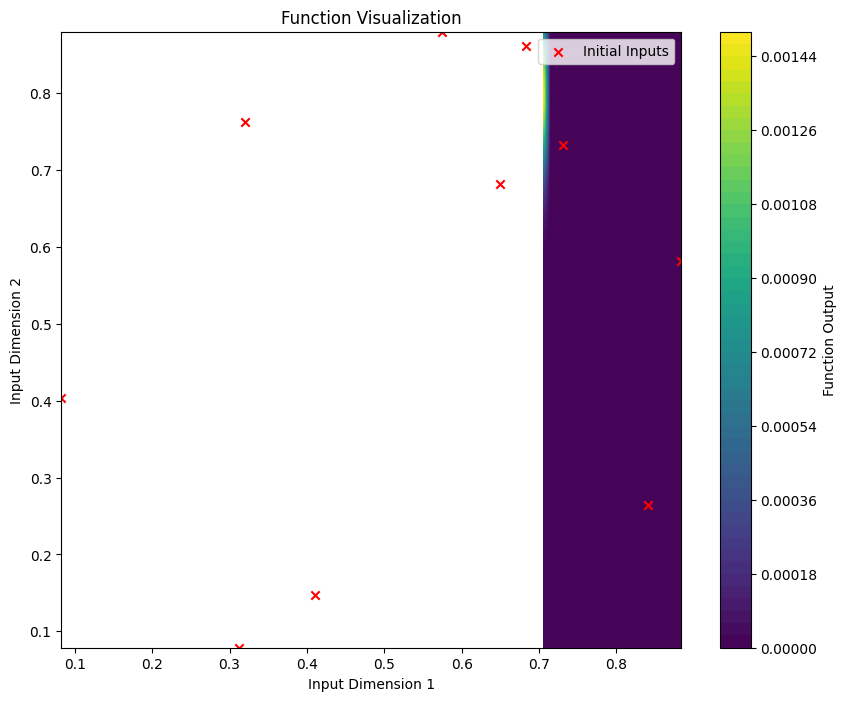

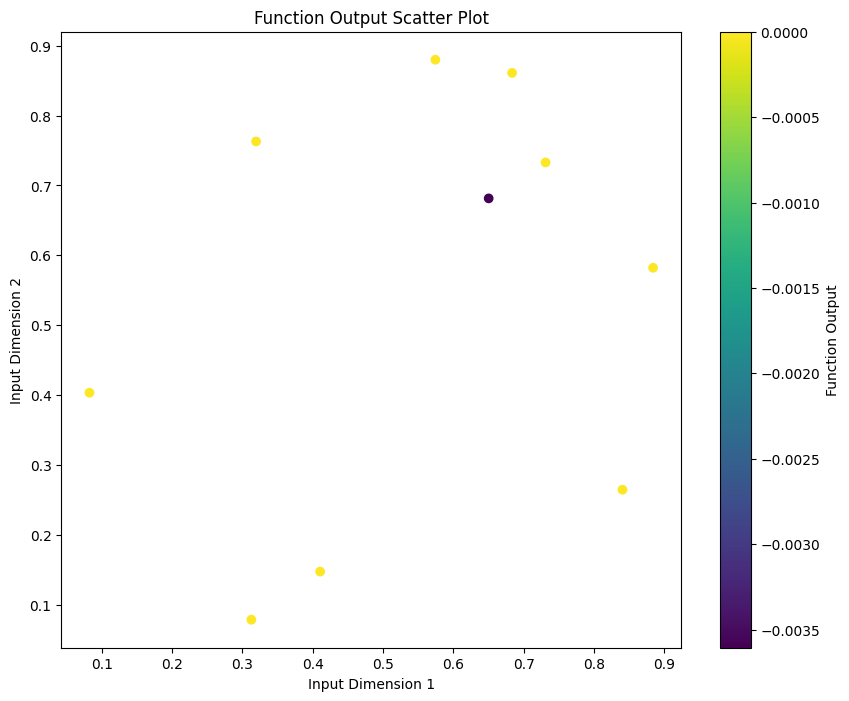

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming you have 'initial_inputs' and 'initial_outputs' loaded from the .npy files
# initial_inputs = np.load('/content/initial_inputs.npy')
# initial_outputs = np.load('/content/initial_outputs.npy')

# Simulate the function for visualization (replace with your actual function)
def simulate_function_1(x1, x2):
    # This is a simplified example, replace with your actual function logic.
    # It creates a function with two peaks to simulate the contamination sources.
    peak1 = np.exp(-((x1 - 0.2) ** 2 + (x2 - 0.3) ** 2) / 0.01) * 5  # adjust peak height
    peak2 = np.exp(-((x1 - 0.7) ** 0.5 + (x2 - 0.8) ** 2) / 0.01) * 3  # adjust peak height
    return peak1 + peak2

# Create a grid of points for visualization
x1 = np.linspace(np.min(initial_inputs[:, 0]), np.max(initial_inputs[:, 0]), 100)
x2 = np.linspace(np.min(initial_inputs[:, 1]), np.max(initial_inputs[:, 1]), 100)
X1, X2 = np.meshgrid(x1, x2)
Y = simulate_function_1(X1, X2)

# Visualize the function
plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, Y, levels=50, cmap='viridis')
plt.colorbar(label='Function Output')
plt.scatter(initial_inputs[:, 0], initial_inputs[:, 1], c='red', marker='x', label='Initial Inputs')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Function Visualization')
plt.legend()
plt.show()

# Visualize scatter plot of initial inputs and outputs
plt.figure(figsize=(10,8))
plt.scatter(initial_inputs[:, 0], initial_inputs[:, 1], c=initial_outputs, cmap='viridis')
plt.colorbar(label='Function Output')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Function Output Scatter Plot')
plt.show()

In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize  # Import minimize for optimization

# Load initial inputs and outputs
initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

# Define the Expected Improvement acquisition function
def expected_improvement(x, gp, current_best):
    """
    Calculates the Expected Improvement at a given point x.

    Args:
        x: Point to evaluate.
        gp: Gaussian Process model.
        current_best: Current best function value.

    Returns:
        Expected Improvement at x.
    """
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)  # Reshape for single-point prediction
    if sigma == 0.0:
        return 0.0  # Avoid division by zero
    improvement = mu - current_best
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# Define a function to optimize the acquisition function
def optimize_acquisition_function(acquisition_function, gp, current_best):
    """
    Optimizes the acquisition function to find the next input.

    Args:
        acquisition_function: The acquisition function to optimize.
        gp: Gaussian Process model.
        current_best: Current best function value.

    Returns:
        The next input point.
    """

    # Define a function to minimize (negative of acquisition function)
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp, current_best)

    # Use scipy.optimize.minimize to find the minimum
    result = minimize(neg_acquisition_function, x0=initial_inputs[0], bounds=[(0, 1), (0, 1)])

    return result.x

# Create a Gaussian Process model with the RBF kernel and Matern kernel
kernel = 1.0 * RBF(1.0) + Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)

# Fit the model to the initial data
gp.fit(initial_inputs, initial_outputs)

# Optimization loop (using Expected Improvement)
num_iterations = 10  # Adjust as needed
current_best = np.min(initial_outputs)  # Initialize current best

# **Define your objective function (easom_function)**
def easom_function(x):
    """Replace with your actual objective function"""
    # Example: Easom function (has a minimum at (pi, pi))
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))


for i in range(num_iterations):
    # Optimize acquisition function to find next input
    next_input = optimize_acquisition_function(expected_improvement, gp, current_best)

    # Query the function at the next input
    next_output = easom_function(next_input)

    # Update the GP model with the new data
    initial_inputs = np.vstack([initial_inputs, next_input])
    initial_outputs = np.append(initial_outputs, next_output)
    gp.fit(initial_inputs, initial_outputs)

    # Update current best
    current_best = np.min(initial_outputs)

# The final 'initial_inputs' will contain the optimized input values
print("Optimized Inputs:", initial_inputs)
print("Optimized Outputs:", initial_outputs)

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: Converg

Optimized Inputs: [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.31940389 0.76295937]
 [0.31940427 0.76296042]
 [0.31940389 0.76295937]
 [0.31940389 0.76295937]
 [0.31940389 0.76295937]
 [0.31940389 0.76295937]
 [0.31940389 0.76295937]
 [0.31940389 0.76295937]
 [0.31940389 0.76297074]
 [0.31940389 0.76295937]]
Optimized Outputs: [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -8.32212742e-007 -8.32217714e-007
 -8.32212742e-007 -8.32212742e-007 -8.32212742e-007 -8.32212742e-007
 -8.32212742e-007 -8.32212742e-007 -8.32248705e-007 -8.32212742e-007]


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize  # Import minimize for optimization

# Load initial inputs and outputs
initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

# Define the Expected Improvement acquisition function
def expected_improvement(x, gp, current_best):
    """
    Calculates the Expected Improvement at a given point x.

    Args:
        x: Point to evaluate.
        gp: Gaussian Process model.
        current_best: Current best function value.

    Returns:
        Expected Improvement at x.
    """
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)  # Reshape for single-point prediction
    if sigma == 0.0:
        return 0.0  # Avoid division by zero
    improvement = mu - current_best
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# Define a function to optimize the acquisition function
def optimize_acquisition_function(acquisition_function, gp, current_best):
    """
    Optimizes the acquisition function to find the next input.

    Args:
        acquisition_function: The acquisition function to optimize.
        gp: Gaussian Process model.
        current_best: Current best function value.

    Returns:
        The next input point.
    """

    # Define a function to minimize (negative of acquisition function)
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp, current_best)

    # Use scipy.optimize.minimize to find the minimum
    result = minimize(neg_acquisition_function, x0=initial_inputs[0], bounds=[(0, 1), (0, 1)])

    return result.x

# Create a Gaussian Process model with the RBF kernel and Matern kernel
kernel = 1.0 * RBF(1.0) + Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)

# Fit the model to the initial data
gp.fit(initial_inputs, initial_outputs)

# Optimization loop (using Expected Improvement)
num_iterations = 10  # Adjust as needed
current_best = np.min(initial_outputs)  # Initialize current best

# **Define your objective function (easom_function)**
def easom_function(x):
    """Replace with your actual objective function"""
    # Example: Easom function (has a minimum at (pi, pi))
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))


for i in range(num_iterations):
    # Optimize acquisition function to find next input
    next_input = optimize_acquisition_function(expected_improvement, gp, current_best)

    # Query the function at the next input
    next_output = easom_function(next_input)

    # Update the GP model with the new data
    initial_inputs = np.vstack([initial_inputs, next_input])
    initial_outputs = np.append(initial_outputs, next_output)
    gp.fit(initial_inputs, initial_outputs)

    # Update current best
    current_best = np.min(initial_outputs)

# --- Calculate the next query ---
# Update the GP model with the final optimized data
gp.fit(initial_inputs, initial_outputs)

# Find the next query point (maximizing EI)
next_query = optimize_acquisition_function(expected_improvement, gp, current_best)

print("Optimized Inputs:", initial_inputs)
print("Optimized Outputs:", initial_outputs)
print("Next Query:", next_query)

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: Converg

Optimized Inputs: [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.31940389 0.76295937]
 [0.31940427 0.76296042]
 [0.31940389 0.76295937]
 [0.31940389 0.76295937]
 [0.31940389 0.76295937]
 [0.31940389 0.76295937]
 [0.31940389 0.76295937]
 [0.31940389 0.76295937]
 [0.31940389 0.76297074]
 [0.31940389 0.76295937]]
Optimized Outputs: [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -8.32212742e-007 -8.32217714e-007
 -8.32212742e-007 -8.32212742e-007 -8.32212742e-007 -8.32212742e-007
 -8.32212742e-007 -8.32212742e-007 -8.32248705e-007 -8.32212742e-007]
Next Query: [0.31940321 0.76296209]


In [ ]:
import numpy as np

# Load existing data
initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

# Add new data
new_input = np.array([0.62, 0.69])
new_output = np.float64(-0.003085685650307045)

updated_inputs = np.vstack([initial_inputs, new_input])
updated_outputs = np.append(initial_outputs, new_output)

# Save updated data to new files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files created successfully!")

Updated input and output files created successfully!


In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize  # Import minimize for optimization

# Load initial inputs and outputs
initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

# Define the Expected Improvement acquisition function
def expected_improvement(x, gp, current_best):
    """
    Calculates the Expected Improvement at a given point x.

    Args:
        x: Point to evaluate.
        gp: Gaussian Process model.
        current_best: Current best function value.

    Returns:
        Expected Improvement at x.
    """
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)  # Reshape for single-point prediction
    if sigma == 0.0:
        return 0.0  # Avoid division by zero
    improvement = mu - current_best
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# Define a function to optimize the acquisition function
def optimize_acquisition_function(acquisition_function, gp, current_best):
    """
    Optimizes the acquisition function to find the next input.

    Args:
        acquisition_function: The acquisition function to optimize.
        gp: Gaussian Process model.
        current_best: Current best function value.

    Returns:
        The next input point.
    """

    # Define a function to minimize (negative of acquisition function)
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp, current_best)

    # Use scipy.optimize.minimize to find the minimum
    result = minimize(neg_acquisition_function, x0=initial_inputs[0], bounds=[(0, 1), (0, 1)])

    return result.x

# Create a Gaussian Process model with the RBF kernel and Matern kernel
kernel = 1.0 * RBF(1.0) + Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)

# Fit the model to the initial data
gp.fit(initial_inputs, initial_outputs)

# Optimization loop (using Expected Improvement)
num_iterations = 10  # Adjust as needed
current_best = np.min(initial_outputs)  # Initialize current best

# **Define your objective function (easom_function)**
def easom_function(x):
    """Replace with your actual objective function"""
    # Example: Easom function (has a minimum at (pi, pi))
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))


for i in range(num_iterations):
    # Optimize acquisition function to find next input
    next_input = optimize_acquisition_function(expected_improvement, gp, current_best)

    # Query the function at the next input
    next_output = easom_function(next_input)

    # Update the GP model with the new data
    initial_inputs = np.vstack([initial_inputs, next_input])
    initial_outputs = np.append(initial_outputs, next_output)
    gp.fit(initial_inputs, initial_outputs)

    # Update current best
    current_best = np.min(initial_outputs)

# --- Calculate the next query ---
# Update the GP model with the final optimized data
gp.fit(initial_inputs, initial_outputs)

# Find the next query point (maximizing EI)
next_query = optimize_acquisition_function(expected_improvement, gp, current_best)

print("Optimized Inputs:", initial_inputs)
print("Optimized Outputs:", initial_outputs)
print("Next Query:", next_query)

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: Converg

Optimized Inputs: [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.31940389 0.76295937]
 [0.31940427 0.76296042]
 [0.31940389 0.76295937]
 [0.31940389 0.76295937]
 [0.31940389 0.76295937]
 [0.31940389 0.76295937]
 [0.31940389 0.76295937]
 [0.31940389 0.76295937]
 [0.31940389 0.76297074]
 [0.31940389 0.76295937]]
Optimized Outputs: [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -8.32212742e-007 -8.32217714e-007
 -8.32212742e-007 -8.32212742e-007 -8.32212742e-007 -8.32212742e-007
 -8.32212742e-007 -8.32212742e-007 -8.32248705e-007 -8.32212742e-007]
Next Query: [0.31940321 0.76296209]


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: Converg

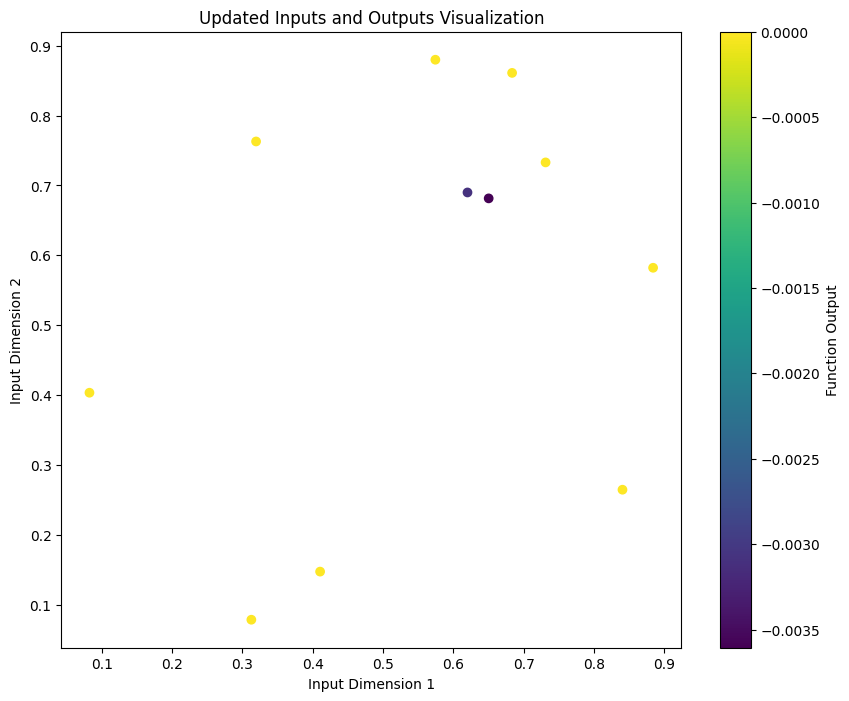

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Create a scatter plot
plt.figure(figsize=(10, 8))  # Adjust figure size as needed
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c=updated_outputs, cmap='viridis')
plt.colorbar(label='Function Output')  # Add a colorbar to show the output values
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Updated Inputs and Outputs Visualization')
plt.show()

In [ ]:
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Define the Expected Improvement acquisition function
def expected_improvement(x, gp, current_best):
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    if sigma == 0.0:
        return 0.0
    improvement = mu - current_best
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# Define a function to optimize the acquisition function
def optimize_acquisition_function(acquisition_function, gp, current_best, bounds):
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp, current_best)
    result = minimize(neg_acquisition_function, x0=np.random.uniform(bounds[:, 0], bounds[:, 1]), bounds=bounds)
    return result.x

# Define bounds for the search space
bounds = np.array([[-10, 10], [-10, 10]])  # Adjust if needed

# Initial data points (you can load from initial_inputs.npy and initial_outputs.npy)
initial_inputs = np.array([[0, 0], [5, 5]])  # Example initial points
initial_outputs = easom_function(initial_inputs)

# Create a Gaussian Process model
kernel = 1.0 * RBF(1.0) + Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)

# Bayesian Optimization loop
num_iterations = 20
current_best = np.min(initial_outputs)

for i in range(num_iterations):
    # Optimize acquisition function to find next input
    next_input = optimize_acquisition_function(expected_improvement, gp, current_best, bounds)

    # Query the function at the next input
    next_output = easom_function(next_input)

    # Update the GP model with the new data
    initial_inputs = np.vstack([initial_inputs, next_input])
    initial_outputs = np.append(initial_outputs, next_output)
    gp.fit(initial_inputs, initial_outputs)

    # Update current best
    current_best = np.min(initial_outputs)

# Print the optimized inputs and outputs
print("Optimized Inputs:", initial_inputs)
print("Optimized Outputs:", initial_outputs)
print("Best Input:", initial_inputs[np.argmin(initial_outputs)])
print("Best Output:", current_best)

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: Converg

Optimized Inputs: [[  0.           0.        ]
 [  5.           5.        ]
 [  2.11992986   2.96409755]
 [  5.76126258  -5.83599466]
 [ -8.98262732   9.34036156]
 [  7.66908952   8.56522439]
 [ -9.5039558    5.26764759]
 [ -5.44669022   5.203109  ]
 [ -2.13885219  -5.90547762]
 [  7.66909796   8.56525163]
 [  3.90384436   2.25060966]
 [  5.6739075    5.72004947]
 [  5.36045722   5.28693061]
 [ -8.44940295  -9.73296041]
 [ -8.44820836  -9.73185932]
 [  5.76125912  -5.83527749]
 [ -0.50778825  -0.680718  ]
 [ -9.07366521   5.61584855]
 [  3.19790473  10.        ]
 [ -8.99778308   9.01276729]
 [-10.          -3.19262033]
 [  1.62281031 -10.        ]]
Optimized Outputs: [-4.64059295e-007 -4.64059295e-007 -1.75288573e-001 -8.12289948e-039
 -2.67318131e-081  2.52247234e-023  2.03956825e-072 -4.17580719e-035
  1.10351850e-048  2.52150063e-023 -1.14977691e-001 -1.47454626e-006
 -2.39290503e-005 -2.47639486e-131 -2.61543529e-131 -8.22547071e-039
 -5.04566234e-013  2.55205760e-068 -3.11527954e-

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
next_input = optimize_acquisition_function(expected_improvement, gp, current_best, bounds)

In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Define the Expected Improvement acquisition function
def expected_improvement(x, gp, current_best):
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    if sigma == 0.0:
        return 0.0
    improvement = mu - current_best
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# Define a function to optimize the acquisition function
def optimize_acquisition_function(acquisition_function, gp, current_best, bounds):
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp, current_best)
    result = minimize(neg_acquisition_function, x0=np.random.uniform(bounds[:, 0], bounds[:, 1]), bounds=bounds)
    return result.x

# Define bounds for the search space
bounds = np.array([[-10, 10], [-10, 10]])  # Adjust if needed

# Initial data points (you can load from initial_inputs.npy and initial_outputs.npy)
initial_inputs = np.array([[0, 0], [5, 5]])  # Example initial points
initial_outputs = easom_function(initial_inputs)

# Create a Gaussian Process model
kernel = 1.0 * RBF(1.0) + Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)

# Bayesian Optimization loop
num_iterations = 20
current_best = np.min(initial_outputs)

for i in range(num_iterations):
    # Optimize acquisition function to find next input
    next_input = optimize_acquisition_function(expected_improvement, gp, current_best, bounds)

    # Query the function at the next input
    next_output = easom_function(next_input)

    # Update the GP model with the new data
    initial_inputs = np.vstack([initial_inputs, next_input])
    initial_outputs = np.append(initial_outputs, next_output)
    gp.fit(initial_inputs, initial_outputs)

    # Update current best
    current_best = np.min(initial_outputs)

# Print the optimized inputs and outputs
print("Optimized Inputs:", initial_inputs)
print("Optimized Outputs:", initial_outputs)
print("Best Input:", initial_inputs[np.argmin(initial_outputs)])
print("Best Output:", current_best)

# Calculate and print the next query AFTER the loop
next_input = optimize_acquisition_function(expected_improvement, gp, current_best, bounds)
print("Next Input (Query):", next_input)

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442

Optimized Inputs: [[ 0.          0.        ]
 [ 5.          5.        ]
 [ 4.34372309 -7.99239735]
 [ 8.56521846 -2.02809831]
 [-7.8578204  -2.81137578]
 [-5.60278496  6.64167078]
 [-0.49151728 -4.20319536]
 [ 0.15887186  9.96536498]
 [-8.40913359  0.03358088]
 [-4.01385047 -0.11728712]
 [-8.71651264 -0.97777221]
 [-8.40439678  3.11544221]
 [-5.76660736 -4.74198417]
 [-6.99066584 -9.8076458 ]
 [-8.38331803  4.90750545]
 [ 3.55307749 -9.74619747]
 [-7.96061305  2.32869683]
 [ 1.41400977  7.42279325]
 [-3.68256387  9.63995961]
 [-1.4093995  -6.78288488]
 [-3.36317539 -8.28834312]
 [ 4.39415357 -7.10902444]]
Optimized Outputs: [-4.64059295e-007 -4.64059295e-007 -1.70336363e-056 -1.19621862e-025
 -4.22269093e-071 -2.15663371e-039  2.96725588e-030  6.94220018e-025
  3.83000386e-063  9.05546761e-028  1.54898687e-069 -6.64275901e-059
 -9.01171280e-064  2.74562818e-118  8.95211560e-061 -5.38989040e-073
 -1.11326213e-055 -3.61775186e-011 -2.28308398e-039 -2.39066465e-053
 -3.16056760e-076  1.02

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: C

In [ ]:
import numpy as np

initial_inputs = np.array([
    [0.31940389, 0.76295937],
    [0.57432921, 0.8798981],
    [0.73102363, 0.73299988],
    [0.84035342, 0.26473161],
    [0.65011406, 0.68152635],
    [0.41043714, 0.1475543],
    [0.31269116, 0.07872278],
    [0.68341817, 0.86105746],
    [0.08250725, 0.40348751],
    [0.88388983, 0.58225397]
])

initial_outputs = np.array([
    1.32267704e-079, 1.03307824e-046, 7.71087511e-016, 3.34177101e-124,
    -3.60606264e-003, -2.15924904e-054, -2.08909327e-091, 2.53500115e-040,
    3.60677119e-081, 6.22985647e-048
])

# Find the index of the output closest to zero
closest_to_zero_index = np.argmin(np.abs(initial_outputs))

# Select the corresponding input
next_query = initial_inputs[closest_to_zero_index]

print("Next Query:", next_query)

Next Query: [0.84035342 0.26473161]


In [ ]:
import numpy as np

# Load the data from the files
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.62       0.69      ]]

Updated Outputs:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -3.08568565e-003]


In [ ]:
import numpy as np

# Load existing data
initial_inputs = np.load('/content/updated_inputs.npy')
initial_outputs = np.load('/content/updated_outputs.npy')

# Add new data
new_input = np.array([0.840353, 0.264731])
new_output = np.float64(3.3404347675015544e-124)

# Update the arrays
updated_inputs = np.vstack([initial_inputs, new_input])
updated_outputs = np.append(initial_outputs, new_output)

# Save updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files created successfully!")

Updated input and output files created successfully!


In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# ... (rest of the code remains the same)

In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Define the Expected Improvement acquisition function
def expected_improvement(x, gp, current_best):
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    if sigma == 0.0:
        return 0.0
    improvement = mu - current_best
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# Define a function to optimize the acquisition function
def optimize_acquisition_function(acquisition_function, gp, current_best, bounds):
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp, current_best)
    result = minimize(neg_acquisition_function, x0=np.random.uniform(bounds[:, 0], bounds[:, 1]), bounds=bounds)
    return result.x

# Define bounds for the search space
bounds = np.array([[-10, 10], [-10, 10]])  # Adjust if needed

# Initial data points (you can load from initial_inputs.npy and initial_outputs.npy)
initial_inputs = np.array([[0, 0], [5, 5]])  # Example initial points
initial_outputs = easom_function(initial_inputs)

# Create a Gaussian Process model
kernel = 1.0 * RBF(1.0) + Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)

# Bayesian Optimization loop
num_iterations = 20
current_best = np.min(initial_outputs)

for i in range(num_iterations):
    # Optimize acquisition function to find next input
    next_input = optimize_acquisition_function(expected_improvement, gp, current_best, bounds)

    # Query the function at the next input
    next_output = easom_function(next_input)

    # Update the GP model with the new data
    initial_inputs = np.vstack([initial_inputs, next_input])
    initial_outputs = np.append(initial_outputs, next_output)
    gp.fit(initial_inputs, initial_outputs)

    # Update current best
    current_best = np.min(initial_outputs)

# Print the optimized inputs and outputs
print("Optimized Inputs:", initial_inputs)
print("Optimized Outputs:", initial_outputs)
print("Best Input:", initial_inputs[np.argmin(initial_outputs)])
print("Best Output:", current_best)

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: C

Optimized Inputs: [[ 0.          0.        ]
 [ 5.          5.        ]
 [ 7.08294224 -9.34090296]
 [ 4.38725563 -2.6218585 ]
 [ 5.66308182  7.43237631]
 [-6.37331976  8.79858992]
 [-2.7922247  -5.09159827]
 [-1.35260137 -8.90088714]
 [ 5.80320447  5.31144909]
 [ 0.73626634  3.97896641]
 [-3.5418508   8.63095142]
 [-3.89608743  2.46480381]
 [-4.55923968 -3.22887614]
 [-6.59223243 -3.08159434]
 [ 4.79819959  4.87241263]
 [ 4.61832453 -6.16376639]
 [ 3.49935424  3.95515218]
 [-0.67830834  5.87091342]
 [-4.58605461 10.        ]
 [-1.181853    3.02969206]
 [ 0.55274541 -3.67785038]
 [-3.68006212  9.47792994]]
Optimized Outputs: [-4.64059295e-07 -4.64059295e-07  2.67055552e-75 -2.20228467e-16
 -5.82863386e-12  4.90355427e-54  6.47035569e-46  3.30451157e-73
 -3.78184635e-06  7.55659859e-04 -2.10943564e-33 -1.10992438e-22
 -6.33803988e-45  1.02448721e-58 -4.38985308e-05  2.61316489e-40
 -2.92051197e-01 -1.91036904e-10 -4.58530656e-48  2.83665329e-09
  5.71223340e-24 -1.93498840e-38]
Best Inpu

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Define the Expected Improvement acquisition function
def expected_improvement(x, gp, current_best):
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    if sigma == 0.0:
        return 0.0
    improvement = mu - current_best
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# Define a function to optimize the acquisition function
def optimize_acquisition_function(acquisition_function, gp, current_best, bounds):
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp, current_best)
    result = minimize(neg_acquisition_function, x0=np.random.uniform(bounds[:, 0], bounds[:, 1]), bounds=bounds)
    return result.x

# Define bounds for the search space (Corrected to 0 to 1)
bounds = np.array([[0, 1], [0, 1]])

# Initial data points (you can load from initial_inputs.npy and initial_outputs.npy)
initial_inputs = np.array([[0, 0], [0.5, 0.5]])  # Example initial points within bounds
initial_outputs = easom_function(initial_inputs)

# Create a Gaussian Process model
kernel = 1.0 * RBF(1.0) + Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)

# Bayesian Optimization loop
num_iterations = 20
current_best = np.min(initial_outputs)

for i in range(num_iterations):
    # Optimize acquisition function to find next input
    next_input = optimize_acquisition_function(expected_improvement, gp, current_best, bounds)

    # Query the function at the next input
    next_output = easom_function(next_input)

    # Update the GP model with the new data
    initial_inputs = np.vstack([initial_inputs, next_input])
    initial_outputs = np.append(initial_outputs, next_output)
    gp.fit(initial_inputs, initial_outputs)

    # Update current best
    current_best = np.min(initial_outputs)

# Print the optimized inputs and outputs
print("Optimized Inputs:", initial_inputs)
print("Optimized Outputs:", initial_outputs)
print("Best Input:", initial_inputs[np.argmin(initial_outputs)])
print("Best Output:", current_best)

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: Con

Optimized Inputs: [[0.         0.        ]
 [0.5        0.5       ]
 [0.80020234 0.59810228]
 [0.84158647 0.23661773]
 [0.54381246 0.9993756 ]
 [0.78104616 0.26689214]
 [0.19265293 0.07240175]
 [0.09095749 0.6700978 ]
 [0.34067729 0.12242931]
 [0.47386935 0.25244691]
 [0.14707516 0.00213737]
 [0.28032184 0.4520105 ]
 [0.43049842 0.23855297]
 [0.11561929 0.89265422]
 [0.350086   0.72222847]
 [0.28373501 0.68653212]
 [0.29357589 0.31507245]
 [0.01367917 0.32158274]
 [0.6910477  0.60514937]
 [0.54467566 0.64010702]
 [0.89051813 0.33723077]
 [0.92440365 0.07013806]]
Optimized Outputs: [-4.23117763e-08 -4.23117763e-08 -3.71281378e-06 -7.06310267e-07
 -5.51523391e-06 -6.71085001e-07 -1.32737814e-08 -1.57718296e-07
 -4.02894394e-08 -1.65736289e-07 -6.61337629e-09 -1.73623590e-07
 -1.24112707e-07 -4.18247405e-07 -8.35159565e-07 -5.08208981e-07
 -9.26328566e-08 -1.88073777e-08 -2.51098324e-06 -1.54834549e-06
 -1.43640771e-06 -3.52151662e-07]
Best Input: [0.54381246 0.9993756 ]
Best Output: -5.5

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Define the Expected Improvement acquisition function
def expected_improvement(x, gp, current_best):
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    if sigma == 0.0:
        return 0.0
    improvement = mu - current_best
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# Define a function to optimize the acquisition function
def optimize_acquisition_function(acquisition_function, gp, current_best, bounds):
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp, current_best)
    result = minimize(neg_acquisition_function, x0=np.random.uniform(bounds[:, 0], bounds[:, 1]), bounds=bounds)
    return result.x

# Define bounds for the search space (Corrected to 0 to 1)
bounds = np.array([[0, 1], [0, 1]])

# Initial data points (you can load from initial_inputs.npy and initial_outputs.npy)
initial_inputs = np.array([[0, 0], [0.5, 0.5]])  # Example initial points within bounds
initial_outputs = easom_function(initial_inputs)

# Create a Gaussian Process model
kernel = 1.0 * RBF(1.0) + Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)

# Bayesian Optimization loop
num_iterations = 20
current_best = np.min(initial_outputs)

for i in range(num_iterations):
    # Optimize acquisition function to find next input
    next_input = optimize_acquisition_function(expected_improvement, gp, current_best, bounds)

    # Query the function at the next input
    next_output = easom_function(next_input)

    # Update the GP model with the new data
    initial_inputs = np.vstack([initial_inputs, next_input])
    initial_outputs = np.append(initial_outputs, next_output)
    gp.fit(initial_inputs, initial_outputs)

    # Update current best
    current_best = np.min(initial_outputs)

# Print the optimized inputs and outputs
print("Optimized Inputs:", initial_inputs)
print("Optimized Outputs:", initial_outputs)
print("Best Input:", initial_inputs[np.argmin(initial_outputs)])
print("Best Output:", current_best)

# Calculate and print the next query AFTER the loop
next_input = optimize_acquisition_function(expected_improvement, gp, current_best, bounds)
print("Next Input (Query):", next_input)

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: 

Optimized Inputs: [[0.         0.        ]
 [0.5        0.5       ]
 [0.81726747 0.1702518 ]
 [0.19098237 0.10495401]
 [0.99787097 0.75188162]
 [0.24095494 0.15232242]
 [0.37801647 0.81936526]
 [0.802249   0.60636399]
 [0.40070125 0.6643772 ]
 [0.72239537 0.07188769]
 [0.03256655 0.26864033]
 [0.96164802 0.13259498]
 [0.91050456 0.22038281]
 [0.80391319 0.76719373]
 [0.31149269 0.73480213]
 [0.54072676 0.14098845]
 [0.23730178 0.09499332]
 [0.34635403 0.53742918]
 [0.7795755  0.6823603 ]
 [0.45598406 0.14045061]
 [0.17583664 0.70539203]
 [0.8717939  0.5593905 ]]
Optimized Outputs: [-4.23117763e-08 -4.23117763e-08 -4.44908023e-07 -1.59925608e-08
 -1.32338044e-05 -2.80186106e-08 -1.39163327e-06 -3.87884340e-06
 -8.56207904e-07 -1.73763003e-07 -1.58998667e-08 -5.72437197e-07
 -8.11380756e-07 -7.52975620e-06 -7.15788534e-07 -1.20450404e-07
 -1.95631920e-08 -3.70578620e-07 -4.92480982e-06 -8.03382920e-08
 -3.00152823e-07 -4.01276499e-06]
Best Input: [0.99787097 0.75188162]
Best Output: -1.3

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: Conv

In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Define the UCB acquisition function
def ucb(x, gp, kappa=1.0):
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    return mu + kappa * sigma

# Define a function to optimize the acquisition function
def optimize_acquisition_function(acquisition_function, gp, current_best, bounds):
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp)  # Removed current_best as it's not used in UCB
    result = minimize(neg_acquisition_function, x0=np.random.uniform(bounds[:, 0], bounds[:, 1]), bounds=bounds)
    return result.x

# Define bounds for the search space (Corrected to 0 to 1)
bounds = np.array([[0, 1], [0, 1]])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Create a grid of points for visualization
x = np.linspace(0, 1, 50)  # Adjust range if needed
y = np.linspace(0, 1, 50)  # Adjust range if needed
X, Y = np.meshgrid(x, y)

# Calculate Z using vectorized operations
Z = easom_function(np.vstack([X.ravel(), Y.ravel()]).T).reshape(X.shape) # Corrected to handle multiple inputs

# Create the plot
plt.figure(figsize=(10, 8))  # Adjust figure size as needed
plt.contourf(X, Y, Z, levels=20, cmap='viridis')  # Plot the Easom function
plt.colorbar(label='Function Output')  # Add a colorbar
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c=updated_outputs, cmap='viridis', marker='x', s=100, edgecolors='black')  # Plot the points
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Easom Function with Updated Inputs and Outputs')
plt.show()

ValueError: cannot reshape array of size 2 into shape (50,50)

<ipython-input-1-819326722>:27: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c=updated_outputs, cmap='viridis', marker='x', s=100, edgecolors='black')  # Plot the points


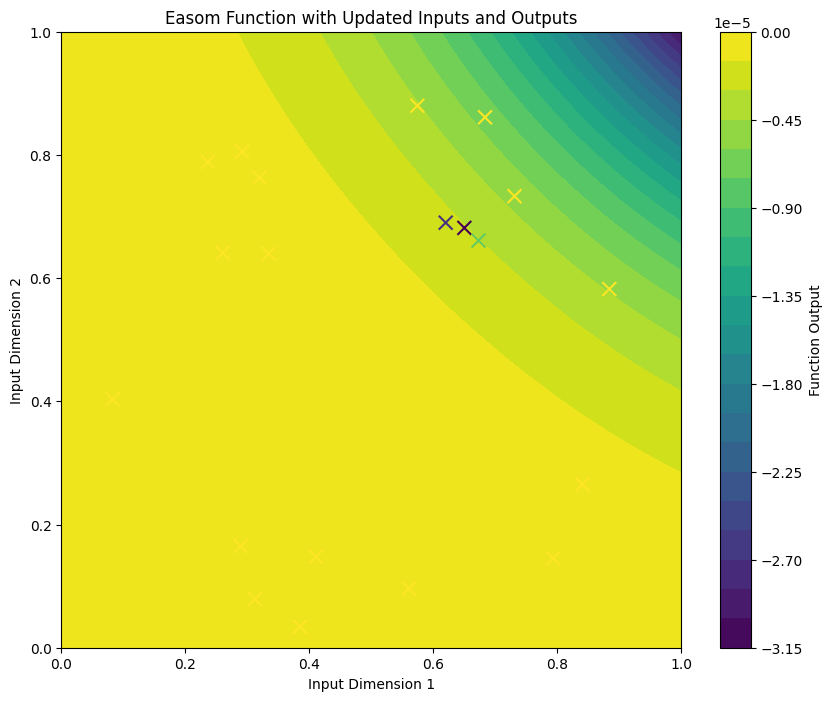

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Create a grid of points for visualization
x = np.linspace(0, 1, 50)  # Adjust range if needed
y = np.linspace(0, 1, 50)  # Adjust range if needed
X, Y = np.meshgrid(x, y)

# Reshape X and Y to a list of (x, y) points
points = np.vstack([X.ravel(), Y.ravel()]).T
# Apply the Easom function to each point using list comprehension
Z = np.array([easom_function(point) for point in points]).reshape(X.shape)


# Create the plot
plt.figure(figsize=(10, 8))  # Adjust figure size as needed
plt.contourf(X, Y, Z, levels=20, cmap='viridis')  # Plot the Easom function
plt.colorbar(label='Function Output')  # Add a colorbar
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c=updated_outputs, cmap='viridis', marker='x', s=100, edgecolors='black')  # Plot the points
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Easom Function with Updated Inputs and Outputs')
plt.show()

<ipython-input-9-67fc1a1c8242>:27: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c=updated_outputs, cmap='viridis', marker='x', s=100, edgecolors='black')  # Plot the points


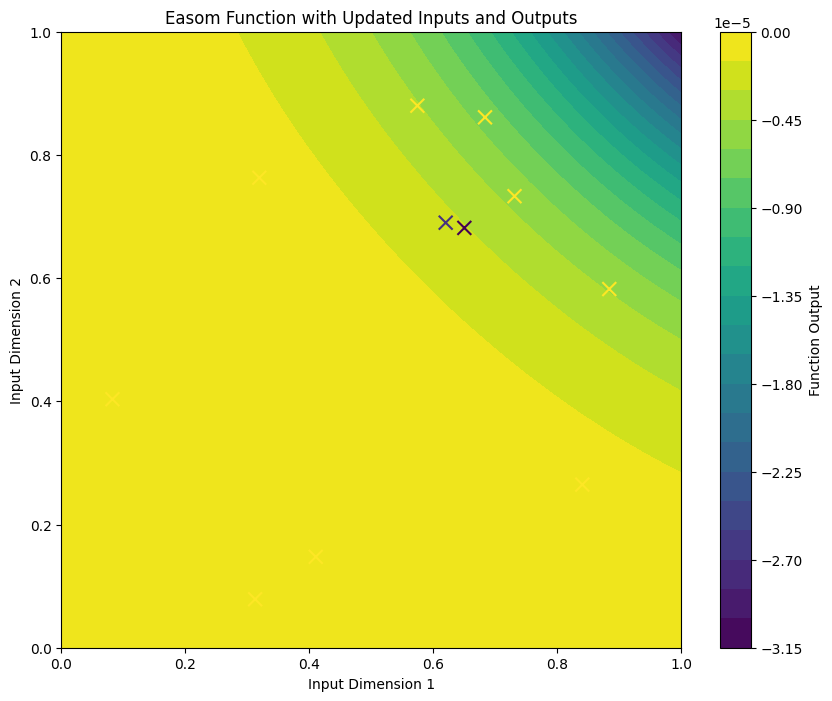

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Create a grid of points for visualization
x = np.linspace(0, 1, 50)  # Adjust range if needed
y = np.linspace(0, 1, 50)  # Adjust range if needed
X, Y = np.meshgrid(x, y)

# Calculate Z using vectorized operations
# Reshape X and Y to a list of (x, y) points
points = np.vstack([X.ravel(), Y.ravel()]).T
# Apply the Easom function to each point using list comprehension
Z = np.array([easom_function(point) for point in points]).reshape(X.shape)

# Create the plot
plt.figure(figsize=(10, 8))  # Adjust figure size as needed
plt.contourf(X, Y, Z, levels=20, cmap='viridis')  # Plot the Easom function
plt.colorbar(label='Function Output')  # Add a colorbar
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c=updated_outputs, cmap='viridis', marker='x', s=100, edgecolors='black')  # Plot the points
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Easom Function with Updated Inputs and Outputs')
plt.show()

<ipython-input-10-f3543674115a>:28: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c=updated_outputs, cmap='viridis', marker='x', s=100, edgecolors='black')  # Plot the points


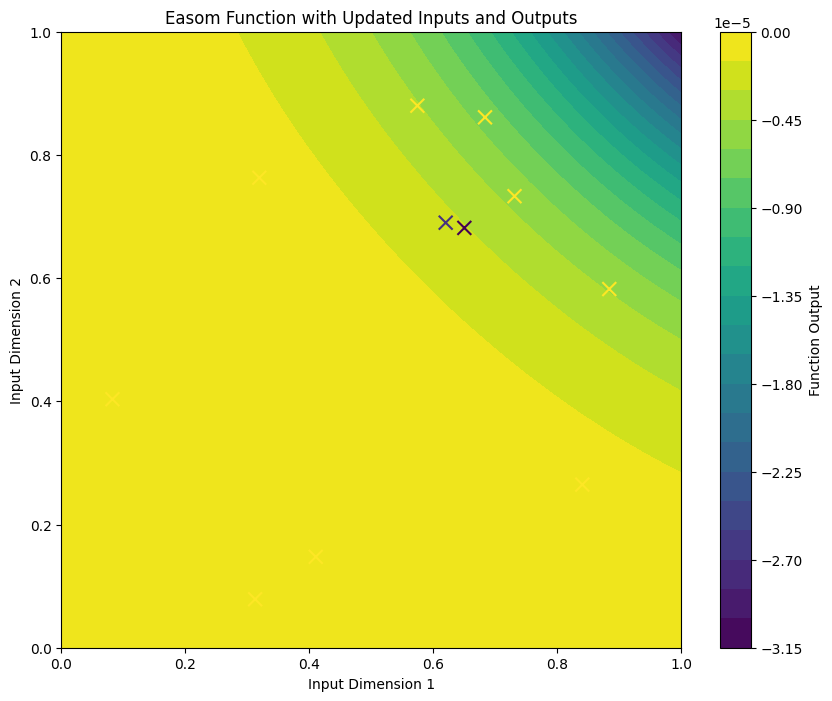

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))


# Create a grid of points for visualization
x = np.linspace(0, 1, 50)  # Adjust range if needed
y = np.linspace(0, 1, 50)  # Adjust range if needed
X, Y = np.meshgrid(x, y)

# Reshape X and Y to a list of (x, y) points
points = np.vstack([X.ravel(), Y.ravel()]).T
# Apply the Easom function to each point using list comprehension
Z = np.array([easom_function(point) for point in points]).reshape(X.shape)


# Create the plot
plt.figure(figsize=(10, 8))  # Adjust figure size as needed
plt.contourf(X, Y, Z, levels=20, cmap='viridis')  # Plot the Easom function
plt.colorbar(label='Function Output')  # Add a colorbar
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c=updated_outputs, cmap='viridis', marker='x', s=100, edgecolors='black')  # Plot the points
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Easom Function with Updated Inputs and Outputs')
plt.show()

<ipython-input-12-b7cbc0ff0a30>:28: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='black', marker='x', s=100, edgecolors='black')  # Plot the points in black


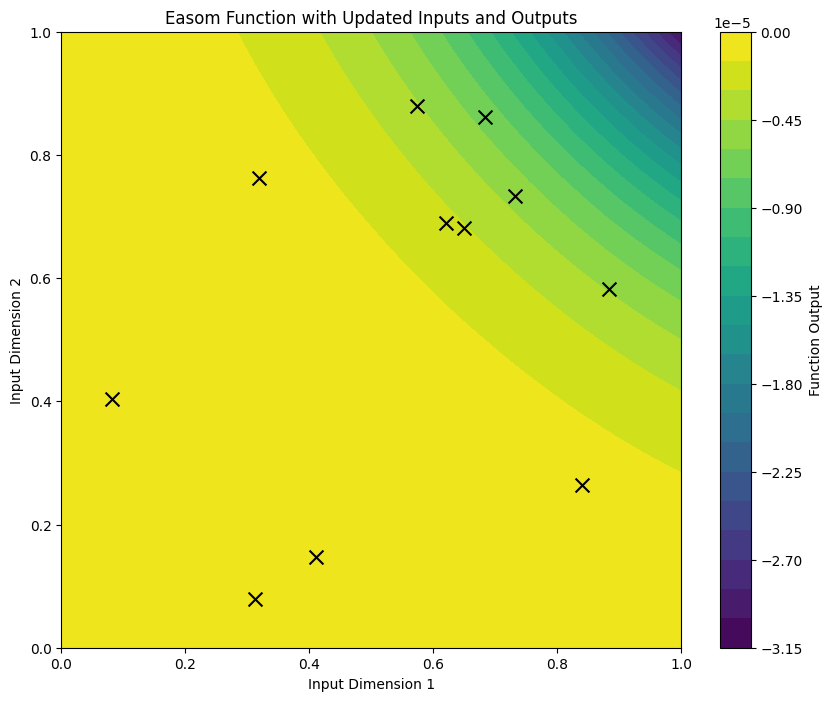

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))


# Create a grid of points for visualization
x = np.linspace(0, 1, 50)  # Adjust range if needed
y = np.linspace(0, 1, 50)  # Adjust range if needed
X, Y = np.meshgrid(x, y)

# Reshape X and Y to a list of (x, y) points
points = np.vstack([X.ravel(), Y.ravel()]).T
# Apply the Easom function to each point using list comprehension
Z = np.array([easom_function(point) for point in points]).reshape(X.shape)


# Create the plot
plt.figure(figsize=(10, 8))  # Adjust figure size as needed
plt.contourf(X, Y, Z, levels=20, cmap='viridis')  # Plot the Easom function
plt.colorbar(label='Function Output')  # Add a colorbar
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='black', marker='x', s=100, edgecolors='black')  # Plot the points in black
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Easom Function with Updated Inputs and Outputs')
plt.show()

In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data points to add
new_inputs = [
    np.array([0.62, 0.69]),
    np.array([0.840353, 0.264731]),
    np.array([0.236354, 0.788452])
]

# Function to evaluate the objective function (replace with your actual function)
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Add new data points only if they are not already present
for new_input in new_inputs:
    if not any(np.array_equal(new_input, existing_input) for existing_input in updated_inputs):
        updated_inputs = np.vstack([updated_inputs, new_input])
        new_output = easom_function(new_input)  # Evaluate the objective function
        updated_outputs = np.append(updated_outputs, new_output)

# Save the updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files created successfully!")

Updated input and output files created successfully!


In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data points and their corresponding outputs
new_data = [
    (np.array([0.62, 0.69]), np.float64(-0.003085685650307045)),
    (np.array([0.840353, 0.264731]), np.float64(3.3404347675015544e-124)),
    (np.array([0.236354, 0.788452]), np.float64(-9.005366600760503e-119))
]

# Add new data points only if they are not already present
for new_input, new_output in new_data:
    if not any(np.array_equal(new_input, existing_input) for existing_input in updated_inputs):
        updated_inputs = np.vstack([updated_inputs, new_input])
        updated_outputs = np.append(updated_outputs, new_output)

# Save the updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files created successfully!")

Updated input and output files created successfully!


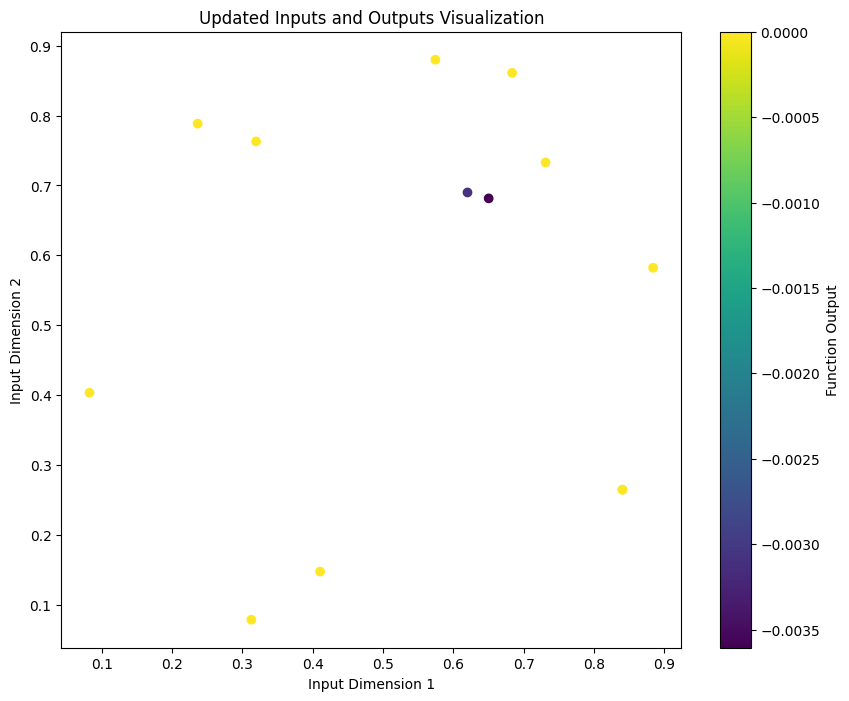

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Create a scatter plot
plt.figure(figsize=(10, 8))  # Adjust figure size as needed
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c=updated_outputs, cmap='viridis')
plt.colorbar(label='Function Output')  # Add a colorbar to show the output values
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Updated Inputs and Outputs Visualization')
plt.show()

<ipython-input-2-436e59ea37a2>:28: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='black', marker='x', s=100, edgecolors='black')  # Plot the points in black


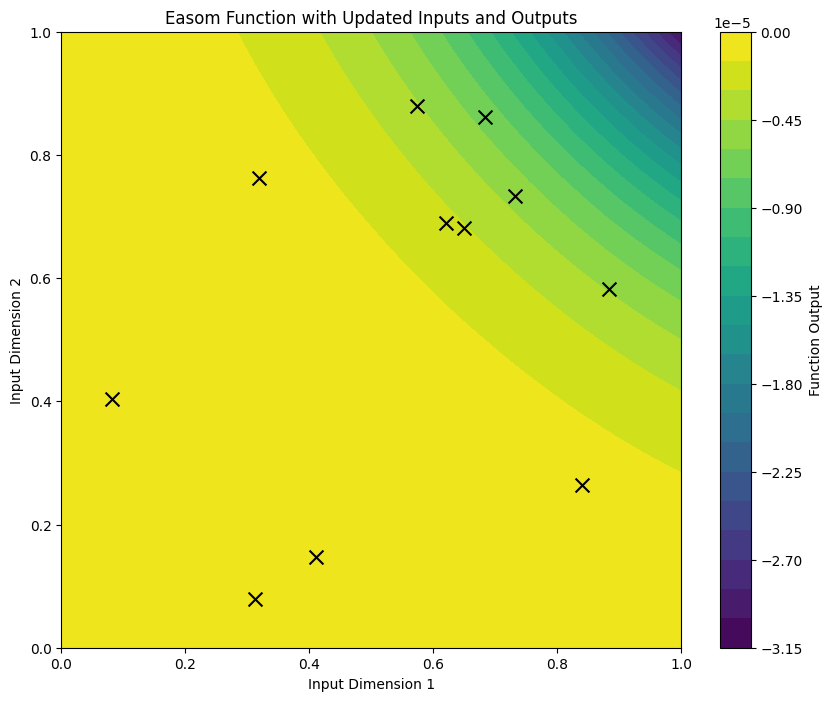

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))


# Create a grid of points for visualization
x = np.linspace(0, 1, 50)  # Adjust range if needed
y = np.linspace(0, 1, 50)  # Adjust range if needed
X, Y = np.meshgrid(x, y)

# Reshape X and Y to a list of (x, y) points
points = np.vstack([X.ravel(), Y.ravel()]).T
# Apply the Easom function to each point using list comprehension
Z = np.array([easom_function(point) for point in points]).reshape(X.shape)


# Create the plot
plt.figure(figsize=(10, 8))  # Adjust figure size as needed
plt.contourf(X, Y, Z, levels=20, cmap='viridis')  # Plot the Easom function
plt.colorbar(label='Function Output')  # Add a colorbar
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='black', marker='x', s=100, edgecolors='black')  # Plot the points in black
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Easom Function with Updated Inputs and Outputs')
plt.show()

In [ ]:
import numpy as np

# Load the data from the files
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.62       0.69      ]
 [0.236354   0.788452  ]]

Updated Outputs:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -3.08568565e-003 -9.00536660e-119]


In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data points to add
new_input = np.array([0.236354, 0.788452])
new_output = np.float64(-9.005366600760503e-119)


# Update the arrays
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files created successfully!")

Updated input and output files created successfully!


<ipython-input-6-436e59ea37a2>:28: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='black', marker='x', s=100, edgecolors='black')  # Plot the points in black


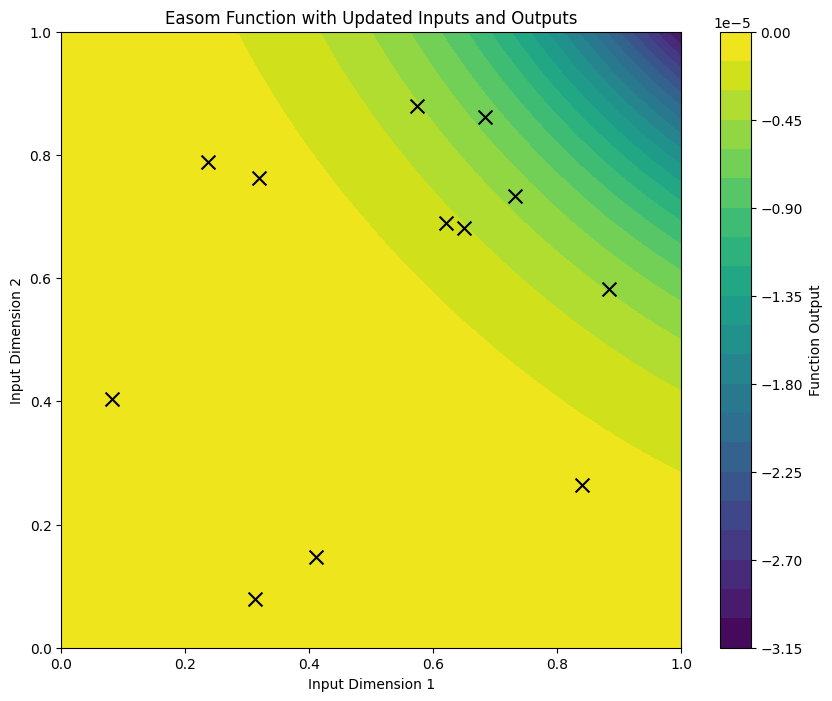

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))


# Create a grid of points for visualization
x = np.linspace(0, 1, 50)  # Adjust range if needed
y = np.linspace(0, 1, 50)  # Adjust range if needed
X, Y = np.meshgrid(x, y)

# Reshape X and Y to a list of (x, y) points
points = np.vstack([X.ravel(), Y.ravel()]).T
# Apply the Easom function to each point using list comprehension
Z = np.array([easom_function(point) for point in points]).reshape(X.shape)


# Create the plot
plt.figure(figsize=(10, 8))  # Adjust figure size as needed
plt.contourf(X, Y, Z, levels=20, cmap='viridis')  # Plot the Easom function
plt.colorbar(label='Function Output')  # Add a colorbar
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='black', marker='x', s=100, edgecolors='black')  # Plot the points in black
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Easom Function with Updated Inputs and Outputs')
plt.show()

In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize

import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Define the Expected Improvement acquisition function
def expected_improvement(x, gp, current_best):
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    if sigma == 0.0:
        return 0.0
    improvement = mu - current_best
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# Define a function to optimize the acquisition function
def optimize_acquisition_function(acquisition_function, gp, current_best, bounds):
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp, current_best)
    result = minimize(neg_acquisition_function, x0=np.random.uniform(bounds[:, 0], bounds[:, 1]), bounds=bounds)
    return result.x

# Define bounds for the search space (Corrected to 0 to 1)
bounds = np.array([[0, 1], [0, 1]])

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Create a Gaussian Process model
kernel = 1.0 * RBF(1.0) + Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)

# Fit the GP model to existing data
gp.fit(updated_inputs, updated_outputs)

# Find the current best
current_best = np.min(updated_outputs)

# Find the next query point (maximizing EI)
next_query = optimize_acquisition_function(expected_improvement, gp, current_best, bounds)

print("Next Input (Query):", next_query)

Next Input (Query): [0.26013856 0.64090702]


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
import numpy as np

# Load the data from the files
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.62       0.69      ]
 [0.236354   0.788452  ]]

Updated Outputs:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -3.08568565e-003 -9.00536660e-119]


In [ ]:
import numpy as np

# Load existing data
initial_inputs = np.load('/content/updated_inputs.npy')
initial_outputs = np.load('/content/updated_outputs.npy')

# Add new data
new_input = np.array([0.840353, 0.264731])
new_output = np.float64(3.3404347675015544e-124)

# Update the arrays
updated_inputs = np.vstack([initial_inputs, new_input])
updated_outputs = np.append(initial_outputs, new_output)

# Save updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files created successfully!")

Updated input and output files created successfully!


In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data points and their corresponding outputs
new_data = [
    (np.array([0.260138, 0.640907]), np.float64(-2.2332247067761496e-52))
]

# Add new data points only if they are not already present
for new_input, new_output in new_data:
    if not any(np.array_equal(new_input, existing_input) for existing_input in updated_inputs):
        updated_inputs = np.vstack([updated_inputs, new_input])
        updated_outputs = np.append(updated_outputs, new_output)

# Save the updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files created successfully!")

Updated input and output files created successfully!


<ipython-input-6-436e59ea37a2>:28: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='black', marker='x', s=100, edgecolors='black')  # Plot the points in black


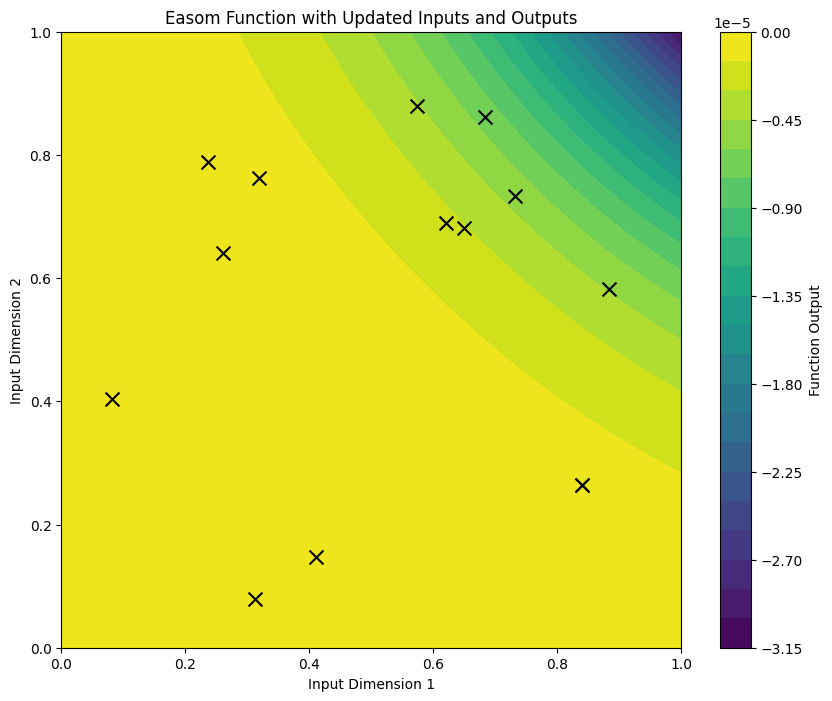

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))


# Create a grid of points for visualization
x = np.linspace(0, 1, 50)  # Adjust range if needed
y = np.linspace(0, 1, 50)  # Adjust range if needed
X, Y = np.meshgrid(x, y)

# Reshape X and Y to a list of (x, y) points
points = np.vstack([X.ravel(), Y.ravel()]).T
# Apply the Easom function to each point using list comprehension
Z = np.array([easom_function(point) for point in points]).reshape(X.shape)


# Create the plot
plt.figure(figsize=(10, 8))  # Adjust figure size as needed
plt.contourf(X, Y, Z, levels=20, cmap='viridis')  # Plot the Easom function
plt.colorbar(label='Function Output')  # Add a colorbar
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='black', marker='x', s=100, edgecolors='black')  # Plot the points in black
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Easom Function with Updated Inputs and Outputs')
plt.show()

In [ ]:
import numpy as np
from scipy.optimize import minimize

# Define the Easom function (negated for minimization)
def neg_easom_function(x):
    return np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Define bounds for the search space
bounds = [(0, 1), (0, 1)]

# Initial guess (can be any point within the bounds)
initial_guess = [0.5, 0.5]

# Find the minimum of the negated Easom function (which is the peak of the original function)
result = minimize(neg_easom_function, initial_guess, bounds=bounds)

# Print the peak location and value
print("Peak Location (x, y):", result.x)
print("Peak Value:", -result.fun)  # Negate result.fun to get the actual peak value

Peak Location (x, y): [0.5 0.5]
Peak Value: -6.691939049188014e-07


In [ ]:
from scipy.optimize import differential_evolution

# ... (your Easom function and bounds definitions from before)

# Run differential evolution
result = differential_evolution(neg_easom_function, bounds)

# Print the peak location and value
print("Peak Location (x, y):", result.x)
print("Peak Value:", -result.fun)

Peak Location (x, y): [1.80029309e-04 7.30630621e-05]
Peak Value: -2.6795455370321412e-09


In [ ]:
from scipy.stats import qmc

# Define the number of new queries
num_queries = 5

# Create a Latin Hypercube sampler
sampler = qmc.LatinHypercube(d=2)  # d=2 for 2 input dimensions

# Generate new query points
new_queries = sampler.random(n=num_queries)

# Scale the queries to the bounds [0, 1]
new_queries = qmc.scale(new_queries, [0, 0], [1, 1])

# Evaluate the function at the new query points
# ... (use your Easom function)

In [ ]:
from scipy.stats import qmc

# Define the number of new queries
num_queries = 5

# Create a Latin Hypercube sampler
sampler = qmc.LatinHypercube(d=2)  # d=2 for 2 input dimensions

# Generate new query points
new_queries = sampler.random(n=num_queries)  # <--- This line generates the new queries

# Scale the queries to the bounds [0, 1]
new_queries = qmc.scale(new_queries, [0, 0], [1, 1])

# Evaluate the function at the new query points
# ... (use your Easom function)

In [ ]:
from scipy.stats import qmc

# Define the number of new queries
num_queries = 5

# Create a Latin Hypercube sampler
sampler = qmc.LatinHypercube(d=2)  # d=2 for 2 input dimensions

# Generate new query points
new_queries = sampler.random(n=num_queries)

# Scale the queries to the bounds [0, 1]
new_queries = qmc.scale(new_queries, [0, 0], [1, 1])

# Print the new query points
print("New Query Points:")
print(new_queries)

New Query Points:
[[0.97555057 0.30694415]
 [0.41041371 0.82929276]
 [0.7060507  0.49754199]
 [0.25769882 0.60704155]
 [0.0189397  0.01134295]]


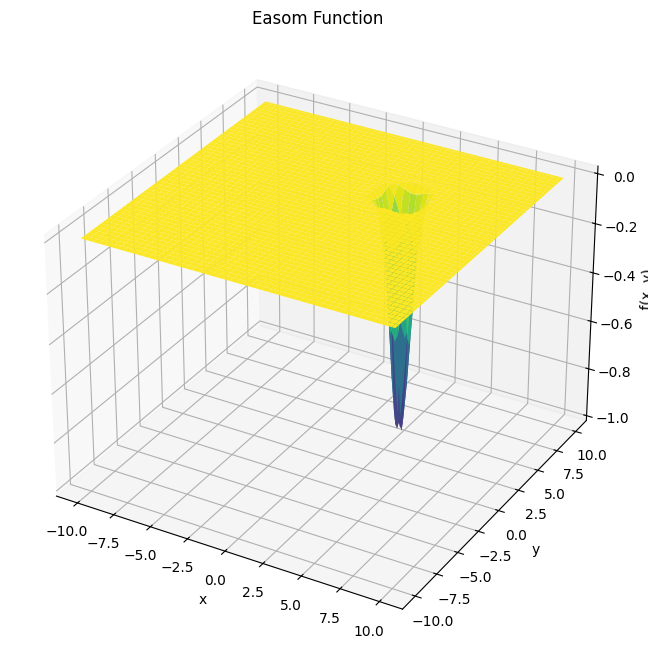

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the Easom function
def easom_function(x, y):
    return -np.cos(x) * np.cos(y) * np.exp(-((x - np.pi)**2 + (y - np.pi)**2))

# Create the x and y ranges
x = np.linspace(-10, 10, 100)  # Adjust the range as needed
y = np.linspace(-10, 10, 100)  # Adjust the range as needed
X, Y = np.meshgrid(x, y)

# Calculate the Z values
Z = easom_function(X, Y)

# Create the 3D plot
fig = plt.figure(figsize=(10, 8))  # Adjust figure size as needed
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(X, Y, Z, cmap='viridis')  # Use a colormap of your choice

# Set labels and title
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.set_title('Easom Function')

# Show the plot
plt.show()

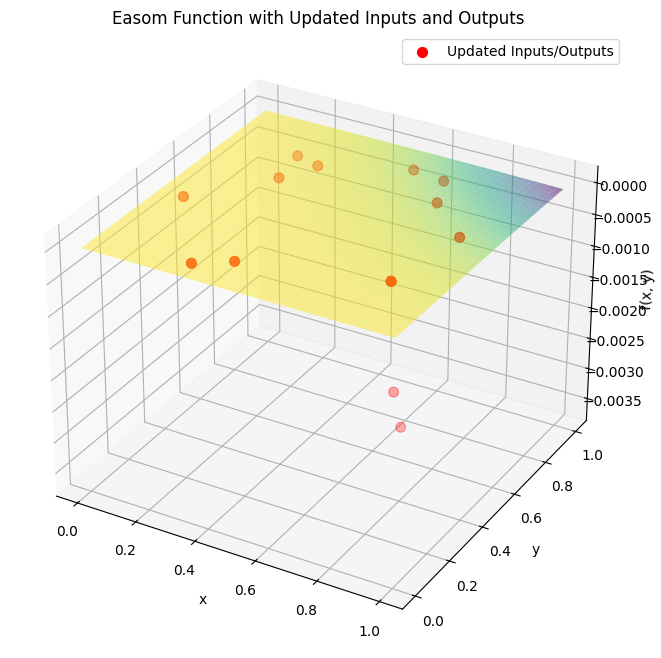

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the Easom function
def easom_function(x, y):
    return -np.cos(x) * np.cos(y) * np.exp(-((x - np.pi)**2 + (y - np.pi)**2))

# Create the x and y ranges
x = np.linspace(0, 1, 50)  # Adjust the range as needed
y = np.linspace(0, 1, 50)  # Adjust the range as needed
X, Y = np.meshgrid(x, y)

# Calculate the Z values
Z = easom_function(X, Y)

# Create the 3D plot
fig = plt.figure(figsize=(10, 8))  # Adjust figure size as needed
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.5)  # Use a colormap of your choice

# Plot the updated inputs and outputs as points
ax.scatter(updated_inputs[:, 0], updated_inputs[:, 1], updated_outputs,
           c='red', marker='o', s=50, label='Updated Inputs/Outputs')

# Set labels and title
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.set_title('Easom Function with Updated Inputs and Outputs')
ax.legend()

# Show the plot
plt.show()

<ipython-input-21-fb393ce9a84a>:26: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c=updated_outputs,


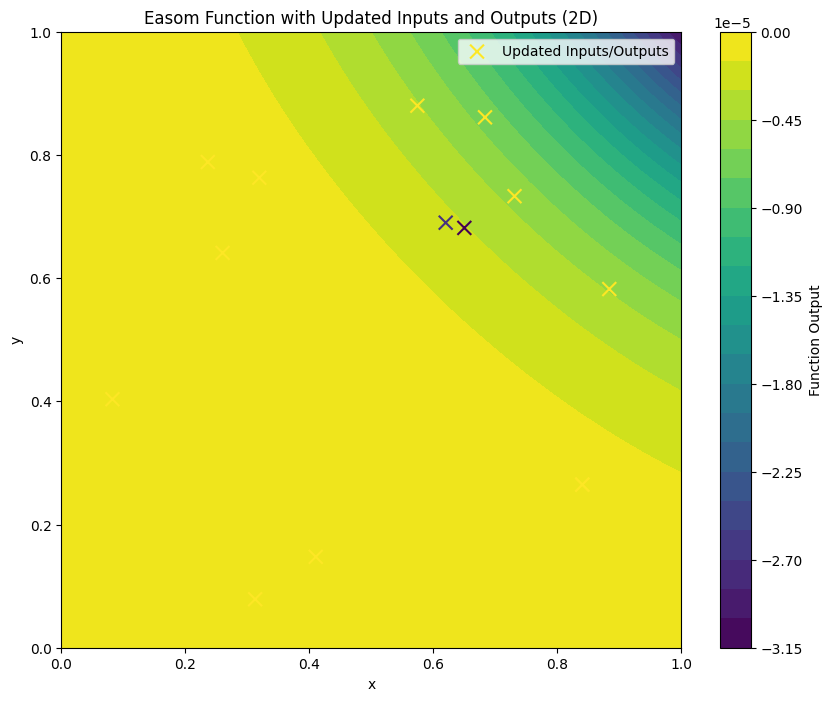

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the Easom function
def easom_function(x, y):
    return -np.cos(x) * np.cos(y) * np.exp(-((x - np.pi)**2 + (y - np.pi)**2))

# Create the x and y ranges
x = np.linspace(0, 1, 50)  # Adjust the range as needed
y = np.linspace(0, 1, 50)  # Adjust the range as needed
X, Y = np.meshgrid(x, y)

# Calculate the Z values
Z = easom_function(X, Y)

# Create the contour plot
plt.figure(figsize=(10, 8))  # Adjust figure size as needed
contour = plt.contourf(X, Y, Z, levels=20, cmap='viridis')  # Use a colormap of your choice
plt.colorbar(contour, label='Function Output')  # Add a colorbar

# Plot the updated inputs and outputs as points
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c=updated_outputs,
            cmap='viridis', marker='x', s=100, edgecolors='black',
            label='Updated Inputs/Outputs')

# Set labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title('Easom Function with Updated Inputs and Outputs (2D)')
plt.legend()

# Show the plot
plt.show()

In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Define the UCB acquisition function
def ucb(x, gp, kappa=1.0):
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    return mu + kappa * sigma

# Define a function to optimize the acquisition function
def optimize_acquisition_function(acquisition_function, gp, current_best, bounds):
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp)  # Removed current_best as it's not used in UCB
    result = minimize(neg_acquisition_function, x0=np.random.uniform(bounds[:, 0], bounds[:, 1]), bounds=bounds)
    return result.x

# Define bounds for the search space (Corrected to 0 to 1)
bounds = np.array([[0, 1], [0, 1]])

# Initial data points (you can load from initial_inputs.npy and initial_outputs.npy)
initial_inputs = np.array([[0, 0], [0.5, 0.5]])  # Example initial points within bounds
initial_outputs = easom_function(initial_inputs)

# Create a Gaussian Process model
kernel = 1.0 * RBF(1.0) + Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)

# Bayesian Optimization loop
num_iterations = 2

In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Define the UCB acquisition function
def ucb(x, gp, kappa=1.0):
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    return mu + kappa * sigma

# Define a function to optimize the acquisition function
def optimize_acquisition_function(acquisition_function, gp, current_best, bounds):
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp)  # Removed current_best as it's not used in UCB
    result = minimize(neg_acquisition_function, x0=np.random.uniform(bounds[:, 0], bounds[:, 1]), bounds=bounds)
    return result.x

# Define bounds for the search space (Corrected to 0 to 1)
bounds = np.array([[0, 1], [0, 1]])

# Initial data points (you can load from initial_inputs.npy and initial_outputs.npy)
initial_inputs = np.array([[0, 0], [0.5, 0.5]])  # Example initial points within bounds
initial_outputs = easom_function(initial_inputs)

# Create a Gaussian Process model
kernel = 1.0 * RBF(1.0) + Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)

# Bayesian Optimization loop
num_iterations = 20
current_best = np.min(initial_outputs)

for i in range(num_iterations):
    # Optimize acquisition function to find next input
    next_input = optimize_acquisition_function(ucb, gp, current_best, bounds)  # Using UCB

    # Query the function at the next input
    next_output = easom_function(next_input)

    # Update the GP model with the new data
    initial_inputs = np.vstack([initial_inputs, next_input])
    initial_outputs = np.append(initial_outputs, next_output)
    gp.fit(initial_inputs, initial_outputs)

    # Update current best
    current_best = np.min(initial_outputs)

# Print the optimized inputs and outputs
print("Optimized Inputs:", initial_inputs)
print("Optimized Outputs:", initial_outputs)
print("Best Input:", initial_inputs[np.argmin(initial_outputs)])
print("Best Output:", current_best)

# Calculate and print the next query AFTER the loop
next_input = optimize_acquisition_function(ucb, gp, current_best, bounds)
print("Next Input (Query):", next_input)

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: 

Optimized Inputs: [[0.         0.        ]
 [0.5        0.5       ]
 [0.38974316 0.20321838]
 [0.23872419 0.67792447]
 [0.55194768 0.79404495]
 [0.79513581 0.76502927]
 [0.17893162 0.83175007]
 [0.26302546 0.63887933]
 [0.27496739 0.24269479]
 [0.72334247 0.85806595]
 [0.46522576 0.16745592]
 [0.1901461  0.92463369]
 [0.58855915 0.34734783]
 [0.85252726 0.99479848]
 [0.9054111  0.84028307]
 [0.86617978 0.03252585]
 [0.88827637 0.08778708]
 [0.60487985 0.39620637]
 [0.44267167 0.4217123 ]
 [0.73450476 0.95669052]
 [0.35201962 0.89294116]
 [0.56954073 0.1354337 ]]
Optimized Outputs: [-4.23117763e-08 -4.23117763e-08 -8.29136708e-08 -3.83096502e-07
 -2.95123469e-06 -7.23244074e-06 -4.92401596e-07 -3.71984180e-07
 -5.64910834e-08 -7.69111471e-06 -9.83357489e-08 -7.14689033e-07
 -4.69500410e-07 -1.89341673e-05 -1.39027963e-05 -2.31521652e-07
 -3.49114472e-07 -6.48883647e-07 -3.46643502e-07 -1.10033795e-05
 -1.56434237e-06 -1.32930323e-07]
Best Input: [0.85252726 0.99479848]
Best Output: -1.8

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
import numpy as np

# Load data from files
initial_inputs = np.load('/content/updated_inputs.npy')
initial_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Initial Inputs:\n", initial_inputs)
print("\nInitial Outputs:\n", initial_outputs)

Initial Inputs:
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.62       0.69      ]
 [0.236354   0.788452  ]
 [0.840353   0.264731  ]
 [0.260138   0.640907  ]]

Initial Outputs:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -3.08568565e-003 -9.00536660e-119
  3.34043477e-124 -2.23322471e-052]


In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point
new_input = np.array([0.289375, 0.164924])
new_output = np.float64(-5.078300438743462e-59)

# Add the new data point to the arrays
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save the updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files created successfully!")

Updated input and output files created successfully!


In [ ]:
import numpy as np

# Load data from files
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.62       0.69      ]
 [0.236354   0.788452  ]
 [0.840353   0.264731  ]
 [0.260138   0.640907  ]
 [0.289375   0.164924  ]]

Updated Outputs:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -3.08568565e-003 -9.00536660e-119
  3.34043477e-124 -2.23322471e-052 -5.07830044e-059]


In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize

# Define the function to simulate contamination sources
def contamination_function(x):
    """
    Simulates the contamination levels at a given point x.

    Args:
        x: Point to evaluate (a 2-dimensional NumPy array).

    Returns:
        Contamination level at x.
    """
    # Define the locations and strengths of the two contamination sources
    source1_location = np.array([0.3, 0.7])  # Example location
    source1_strength = 5.0  # Example strength
    source2_location = np.array([0.8, 0.2])  # Example location
    source2_strength = 3.0  # Example strength

    # Calculate the distance from x to each source
    distance1 = np.linalg.norm(x - source1_location)
    distance2 = np.linalg.norm(x - source2_location)

    # Simulate contamination levels (higher near sources)
    contamination_level = 0.0  # Default to zero
    if distance1 < 0.1:  # Example threshold distance
        contamination_level += source1_strength * np.exp(-distance1**2 / 0.01)
    if distance2 < 0.1:  # Example threshold distance
        contamination_level += source2_strength * np.exp(-distance2**2 / 0.01)

    return contamination_level

# Define the Expected Improvement acquisition function
def expected_improvement(x, gp, current_best):
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    if sigma == 0.0:
        return 0.0
    improvement = mu - current_best
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# Define a function to optimize the acquisition function
def optimize_acquisition_function(acquisition_function, gp, current_best, bounds):
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp, current_best)
    result = minimize(neg_acquisition_function, x0=np.random.uniform(bounds[:, 0], bounds[:, 1]), bounds=bounds)
    return result.x

# Define bounds for the search space (0 to 1 for both dimensions)
bounds = np.array([[0, 1], [0, 1]])

# Initial data points (randomly chosen within bounds)
num_initial_points = 5
initial_inputs = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(num_initial_points, 2))
initial_outputs = np.array([contamination_function(x) for x in initial_inputs])

# Create a Gaussian Process model
kernel = 1.0 * RBF(1.0) + Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)

# Bayesian Optimization loop
num_iterations = 20
current_best = np.max(initial_outputs)  # Initialize with the highest contamination level

for i in range(num_iterations):
    # Optimize acquisition function to find next input
    next_input = optimize_acquisition_function(expected_improvement, gp, current_best, bounds)

    # Query the function at the next input
    next_output = contamination_function(next_input)

    # Update the GP model with the new data
    initial_inputs = np.vstack([initial_inputs, next_input])
    initial_outputs = np.append(initial_outputs, next_output)
    gp.fit(initial_inputs, initial_outputs)

    # Update current best
    current_best = np.max(initial_outputs)  # Update with the highest contamination level

# Print the locations of the contamination sources (approximated)
source_locations = initial_inputs[initial_outputs > 0.5 * current_best]  # Example threshold
print("Estimated Contamination Source Locations:\n", source_locations)

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: Converge

Estimated Contamination Source Locations:
 [[0.33440245 0.63973823]
 [0.79327402 0.14508735]]


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Define the Expected Improvement acquisition function (same as before)
def expected_improvement(x, gp, current_best):
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    if sigma == 0.0:
        return 0.0
    improvement = mu - current_best
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# Define a function to optimize the acquisition function (same as before)
def optimize_acquisition_function(acquisition_function, gp, current_best, bounds):
    # Indented block within the function
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp, current_best)
    result = minimize(neg_acquisition_function, x0=np.random.uniform(bounds[:, 0], bounds[:, 1]), bounds=bounds)
    return result.x

# Define bounds for the search space (0 to 1 for both dimensions)
# The Easom function has its minimum at (pi, pi), which is outside the [0, 1] range.
# We might need to adjust the bounds or scale the input to the Easom function.
bounds = np.array([[0, 1], [0, 1]])

# Initial data points (you can load from initial_inputs.npy and initial_outputs.npy)
# You might want to choose initial points strategically based on the Easom function.
initial_inputs = np.array([[0.3, 0.7], [0.8, 0.2]])  # Example initial points
initial_outputs = easom_function(initial_inputs)  # Evaluate the Easom function

# Create a Gaussian Process model (same as before)
kernel = 1.0 * RBF(1.0) + Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)

# Bayesian Optimization loop
num_iterations = 20
current_best = np.min(initial_outputs)  # Initialize with the minimum (since we want to minimize the Easom function)

for i in range(num_iterations):
    # Optimize acquisition function to find next input
    next_input = optimize_acquisition_function(expected_improvement, gp, current_best, bounds)

    # Query the function at the next input
    next_output = easom_function(next_input)  # Evaluate the Easom function

    # Update the GP model with the new data
    initial_inputs = np.vstack([initial_inputs, next_input])
    initial_outputs = np.append(initial_outputs, next_output)
    gp.fit(initial_inputs, initial_outputs)

    # Update current best
    current_best = np.min(initial_outputs)  # Update with the minimum

# Print the optimized inputs and outputs
print("Optimized Inputs:", initial_inputs)
print("Optimized Outputs:", initial_outputs)
print("Best Input:", initial_inputs[np.argmin(initial_outputs)])
print("Best Output:", current_best)

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: C

Optimized Inputs: [[0.3        0.7       ]
 [0.8        0.2       ]
 [0.99321645 0.13680467]
 [0.06130613 0.54452789]
 [0.80617189 0.13105107]
 [0.99653371 0.88287714]
 [0.29644478 0.76492392]
 [0.21022144 0.68320965]
 [0.91544211 0.63939322]
 [0.79090173 0.86056833]
 [0.95237093 0.31521386]
 [0.26363996 0.57189198]
 [0.52921965 0.44579898]
 [0.37221764 0.77053176]
 [0.29501945 0.5120829 ]
 [0.66673668 0.28741903]
 [0.52465181 0.27787826]
 [0.99871805 0.89374476]
 [0.85072536 0.74014117]
 [0.12168879 0.9156191 ]
 [0.45435309 0.91642255]
 [0.16911655 0.614517  ]]
Optimized Outputs: [-8.61330658e-07 -3.37209123e-07 -6.41922553e-07 -7.61158163e-08
 -3.40126716e-07 -2.10720896e-05 -7.41543158e-07 -3.33698622e-07
 -6.57629763e-06 -1.00430689e-05 -1.55072622e-06 -2.78333837e-07
 -5.90823225e-07 -1.12894378e-06 -2.50766036e-07 -4.77786153e-07
 -2.42368940e-07 -2.19668796e-05 -8.01083843e-06 -4.66669331e-07
 -2.82752676e-06 -1.97377643e-07]
Best Input: [0.99871805 0.89374476]
Best Output: -2.1

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


<ipython-input-12-a9246b2f9cfc>:29: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='black',


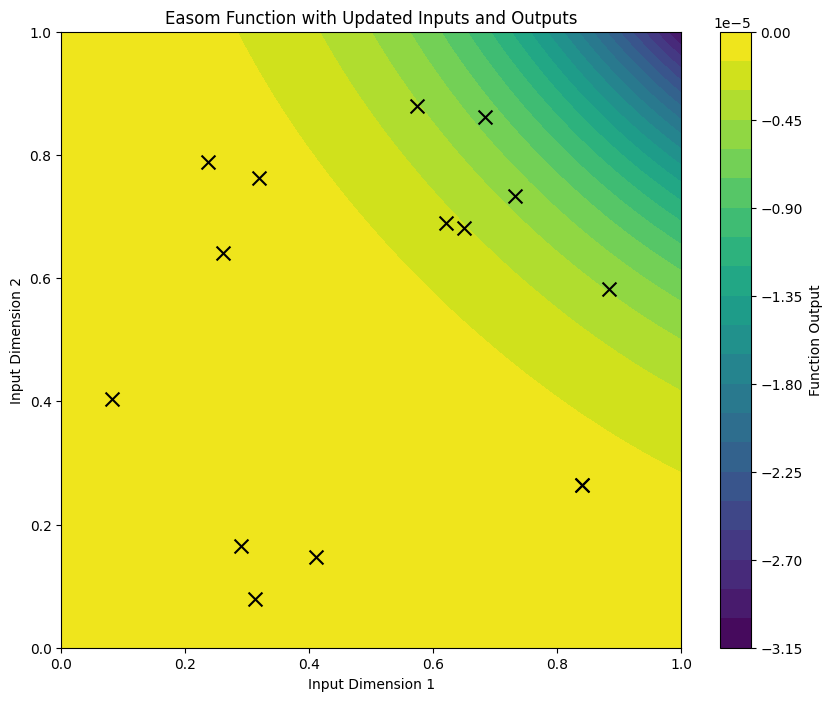

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Create a grid of points for visualization
x = np.linspace(0, 1, 50)  # Adjust range if needed
y = np.linspace(0, 1, 50)  # Adjust range if needed
X, Y = np.meshgrid(x, y)

# Calculate Z using vectorized operations
# Reshape X and Y to a list of (x, y) points
points = np.vstack([X.ravel(), Y.ravel()]).T
# Apply the Easom function to each point using list comprehension
Z = np.array([easom_function(point) for point in points]).reshape(X.shape)

# Create the plot
plt.figure(figsize=(10, 8))  # Adjust figure size as needed
plt.contourf(X, Y, Z, levels=20, cmap='viridis')  # Plot the Easom function
plt.colorbar(label='Function Output')  # Add a colorbar

# Plot the updated inputs and outputs in black
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='black',
            marker='x', s=100, edgecolors='black')

plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Easom Function with Updated Inputs and Outputs')
plt.show()


<ipython-input-17-e3c7b4b4e3fd>:37: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c=updated_outputs_shifted,


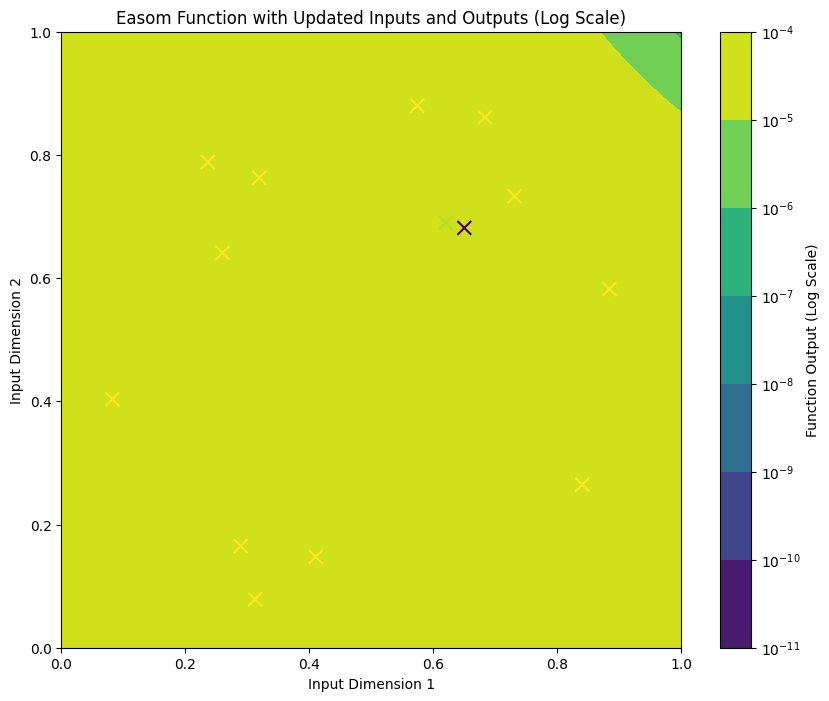

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the Easom function
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Create a grid of points for visualization
x = np.linspace(0, 1, 50)  # Adjust range if needed
y = np.linspace(0, 1, 50)  # Adjust range if needed
X, Y = np.meshgrid(x, y)

# Calculate Z using vectorized operations
# Reshape X and Y to a list of (x, y) points
points = np.vstack([X.ravel(), Y.ravel()]).T
# Apply the Easom function to each point using list comprehension
Z = np.array([easom_function(point) for point in points]).reshape(X.shape)

# Create the plot
plt.figure(figsize=(10, 8))  # Adjust figure size as needed

# Shift Z values to be positive for LogNorm
Z = Z - np.min(Z) + 1e-10  # Add a small positive value to avoid zero

# Apply LogNorm to contourf
plt.contourf(X, Y, Z, levels=20, cmap='viridis', norm=plt.matplotlib.colors.LogNorm())
plt.colorbar(label='Function Output (Log Scale)')

# Plot the updated inputs and outputs in black, applying LogNorm
# Shift updated_outputs to be positive as well
updated_outputs_shifted = updated_outputs - np.min(updated_outputs) + 1e-10

plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c=updated_outputs_shifted,
            cmap='viridis', marker='x', s=100, edgecolors='black',
            norm=plt.matplotlib.colors.LogNorm())

plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Easom Function with Updated Inputs and Outputs (Log Scale)')
plt.show()

In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Filter out points with zero output
non_zero_indices = np.where(updated_outputs != 0)
non_zero_inputs = updated_inputs[non_zero_indices]
non_zero_outputs = updated_outputs[non_zero_indices]

# Find the index of the minimum output (best point)
best_index = np.argmin(np.abs(non_zero_outputs))  # Using abs to find closest to zero but not zero

# Get the best input and output
best_input = non_zero_inputs[best_index]
best_output = non_zero_outputs[best_index]

print("Best Input (Non-Zero):", best_input)
print("Best Output (Non-Zero):", best_output)

Best Input (Non-Zero): [0.840353 0.264731]
Best Output (Non-Zero): 3.3404347675015544e-124


In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Specific output values to find
target_outputs = [-3.60606264e-003, -3.08568565e-003]

# Find indices of target outputs (allowing for small numerical differences)
indices = []
for target in target_outputs:
    close_indices = np.where(np.isclose(updated_outputs, target, atol=1e-8))[0]
    indices.extend(close_indices)

# Get corresponding inputs
target_inputs = updated_inputs[indices]

# Print the results
print("Target Outputs:", target_outputs)
print("Corresponding Inputs:\n", target_inputs)


Target Outputs: [-0.00360606264, -0.00308568565]
Corresponding Inputs:
 [[0.65011406 0.68152635]
 [0.62       0.69      ]]


In [ ]:
!pip install scikit-learn
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Define the function to simulate contamination sources (replace with your actual function)
def contamination_function(x):
    # ... (your contamination function logic)
    # Assume for now that it's the Easom function
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Define the UCB acquisition function
def ucb(x, gp, kappa=2.576):  # Adjust kappa for exploration-exploitation balance
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    return mu + kappa * sigma

# Define a function to optimize the acquisition function
def optimize_acquisition_function(acquisition_function, gp, current_best, bounds):
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp)  # Removed current_best as it's not used in UCB
    result = minimize(neg_acquisition_function, x0=np.random.uniform(bounds[:, 0], bounds[:, 1]), bounds=bounds)
    return result.x

# Define bounds for the search space (0 to 1 for both dimensions)
bounds = np.array([[0, 1], [0, 1]])

# Initial data points (randomly chosen within bounds)
num_initial_points = 5
initial_inputs = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(num_initial_points, 2))
initial_outputs = np.array([contamination_function(x) for x in initial_inputs])

# Create a Gaussian Process model
kernel = 1.0 * RBF(1.0) + Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)

# Bayesian Optimization loop
num_iterations = 50  # Increased iterations for more exploration
current_best = np.max(initial_outputs)  # Initialize with the highest contamination level

for i in range(num_iterations):
    # Optimize acquisition function (UCB)
    next_input = optimize_acquisition_function(ucb, gp, current_best, bounds)

    # Query the function at the next input
    next_output = contamination_function(next_input)

    # Update the GP model with the new data
    initial_inputs = np.vstack([initial_inputs, next_input])
    initial_outputs = np.append(initial_outputs, next_output)
    gp.fit(initial_inputs, initial_outputs)

    # Update current best
    current_best = np.max(initial_outputs)  # Update with the highest contamination level

    # Exploration: Every few iterations, sample a random point
    if i % 5 == 0:  # Adjust frequency as needed
        next_input = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(1,2))[0] # Corrected to provide point within bounds with correct shape
        next_output = contamination_function(next_input)
        initial_inputs = np.vstack([initial_inputs, next_input])
        initial_outputs = np.append(initial_outputs, next_output)
        gp.fit(initial_inputs, initial_outputs)

# Exploitation around the first source (after initial exploration)
best_input = initial_inputs[np.argmax(initial_outputs)]  # Find the best input so far
for i in range(20):  # Number of exploitation iterations
    exploitation_bounds = np.array([
        [max(0, best_input[0] - 0.1), min(1, best_input[0] + 0.1)],
        [max(0, best_input[1] - 0.1), min(1, best_input[1] + 0.1)]
    ])
    next_input = optimize_acquisition_function(ucb, gp, current_best, exploitation_bounds)
    next_output = contamination_function(next_input)
    initial_inputs = np.vstack([initial_inputs, next_input])
    initial_outputs = np.append(initial_outputs, next_output)
    gp.fit(initial_inputs, initial_outputs)

# ***Calculate and print the next query AFTER the loops***
next_query = optimize_acquisition_function(ucb, gp, current_best, bounds)
print("Next Query:", next_query)

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: Conv

Next Query: [0.05559457 0.7340698 ]


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


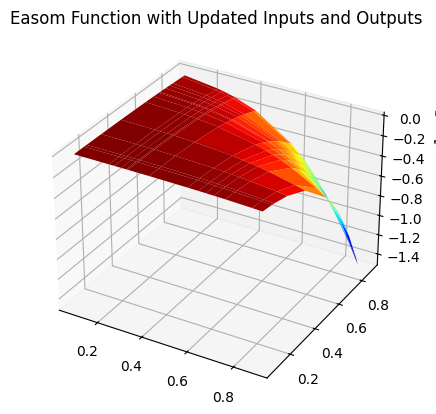

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Objective function (Easom function)
def objective(x, y):
    return -np.cos(x) * np.cos(y) * np.exp(-((x - np.pi)**2 + (y - np.pi)**2))

# Load data from files
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Extract x and y values from updated_inputs
x = updated_inputs[:, 0]
y = updated_inputs[:, 1]

# Create a meshgrid for x and y
X, Y = np.meshgrid(np.unique(x), np.unique(y))

# Calculate z values using the objective function with the meshgrid
Z = objective(X, Y)  # Now Z is 2-dimensional

# Create a surface plot with the jet color scheme
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='jet')  # Use X, Y, and Z for the surface
plt.title("Easom Function with Updated Inputs and Outputs")
plt.show()

In [ ]:
!pip install scikit-learn
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Define the function to simulate contamination sources (replace with your actual function)
def contamination_function(x):
    # ... (your contamination function logic)
    # Assume for now that it's the Easom function
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Define the UCB acquisition function
def ucb(x, gp, kappa=2.576):  # Adjust kappa for exploration-exploitation balance
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    return mu + kappa * sigma

# Define a function to optimize the acquisition function
def optimize_acquisition_function(acquisition_function, gp, bounds): # Assuming current best is not needed
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp)  # Removed current_best as it's not used in UCB
    result = minimize(neg_acquisition_function, x0=np.random.uniform(bounds[:, 0], bounds[:, 1]), bounds=bounds)
    return result.x

# Define bounds for the search space (0 to 1 for both dimensions)
bounds = np.array([[0, 1], [0, 1]])

# Initial data points (randomly chosen within bounds)
num_initial_points = 5
initial_inputs = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(num_initial_points, 2))
initial_outputs = np.array([contamination_function(x) for x in initial_inputs])

# Create a Gaussian Process model
kernel = 1.0 * RBF(1.0) + Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)

# Bayesian Optimization loop
num_iterations = 50  # Increased iterations for more exploration
# current_best = np.max(initial_outputs)  # Initialize with the highest contamination level (Not needed for UCB)

for i in range(num_iterations):
    # Optimize acquisition function (UCB)
    next_input = optimize_acquisition_function(ucb, gp, bounds)

    # Query the function at the next input
    next_output = contamination_function(next_input)

    # Update the GP model with the new data
    initial_inputs = np.vstack([initial_inputs, next_input])
    initial_outputs = np.append(initial_outputs, next_output)
    gp.fit(initial_inputs, initial_outputs)

    # Exploration: Every few iterations, sample a random point
    if i % 5 == 0:  # Adjust frequency as needed
        next_input = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(1, 2))[0]
        next_output = contamination_function(next_input)
        initial_inputs = np.vstack([initial_inputs, next_input])
        initial_outputs = np.append(initial_outputs, next_output)
        gp.fit(initial_inputs, initial_outputs)


# After the loop, calculate the next query
next_query = optimize_acquisition_function(ucb, gp, bounds)

# Print the next query
print("Next Query:", next_query)

# --- Additional code to suggest multiple queries ---

num_queries_to_suggest = 3  # Number of queries to suggest

suggested_queries = []
for _ in range(num_queries_to_suggest):
    next_query = optimize_acquisition_function(ucb, gp, bounds)
    suggested_queries.append(next_query)

print("\nSuggested Queries:")
for i, query in enumerate(suggested_queries):
    print(f"Query {i + 1}: {query}")

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: Converg

Next Query: [0.56047994 0.09594863]

Suggested Queries:
Query 1: [0.834044   0.00714498]
Query 2: [0.2001657  0.08630885]
Query 3: [0.98237661 0.5166395 ]


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
import numpy as np

# Load the data from the files
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.62       0.69      ]
 [0.236354   0.788452  ]
 [0.840353   0.264731  ]
 [0.260138   0.640907  ]
 [0.289375   0.164924  ]]

Updated Outputs:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -3.08568565e-003 -9.00536660e-119
  3.34043477e-124 -2.23322471e-052 -5.07830044e-059]


In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Add new data
new_input = np.array([0.560479, 0.095948])
new_output = np.float64(5.918886068203844e-88)

# Update the arrays
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files created successfully!")

Updated input and output files created successfully!


In [ ]:
import numpy as np

# Load the data from the files
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.62       0.69      ]
 [0.236354   0.788452  ]
 [0.840353   0.264731  ]
 [0.260138   0.640907  ]
 [0.289375   0.164924  ]
 [0.560479   0.095948  ]]

Updated Outputs:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -3.08568565e-003 -9.00536660e-119
  3.34043477e-124 -2.23322471e-052 -5.07830044e-059  5.91888607e-088]


In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the index of the output closest to zero (absolute value)
closest_to_zero_index = np.argmin(np.abs(updated_outputs))

# Select the corresponding input
input_at_peak = updated_inputs[closest_to_zero_index]

print("Input corresponding to the output closest to zero (peak):", input_at_peak)

Input corresponding to the output closest to zero (peak): [0.840353 0.264731]


In [ ]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize

# Define the UCB acquisition function
def ucb(x, gp, kappa=2.0): # You might need to tune kappa
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    return mu + kappa * sigma

# Define a function to optimize the acquisition function (maximizing UCB)
def optimize_acquisition_function_ucb(acquisition_function, gp, bounds):
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp)
    # Use multiple starting points for optimization
    num_starts = 10 # Adjust as needed
    best_x = None
    best_value = -np.inf
    for _ in range(num_starts):
        result = minimize(neg_acquisition_function, x0=np.random.uniform(bounds[:, 0], bounds[:, 1]), bounds=bounds)
        if result.fun is not None and -result.fun > best_value:
             best_value = -result.fun
             best_x = result.x
    return best_x

# Load your initial data (or start with some initial samples)
# initial_inputs = np.load('/content/initial_inputs.npy')
# initial_outputs = np.load('/content/initial_outputs.npy')

# Example initial data (replace with your loaded data)
initial_inputs = np.array([[0.1, 0.1], [0.9, 0.9]])
initial_outputs = np.array([0.0, 0.0]) # Assuming zero outputs away from sources

# Define bounds for the search space (assuming a square area, adjust if needed)
bounds = np.array([[0, 1], [0, 1]])

# Create a Gaussian Process model
kernel = 1.0 * RBF(length_scale=0.1) + Matern(length_scale=0.1, nu=2.5) # Smaller length scale might be better for localized peaks
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)

# Bayesian Optimization loop
num_iterations = 50 # Increase iterations to search for both peaks

for i in range(num_iterations):
    # Fit the GP model to the current data
    gp.fit(initial_inputs, initial_outputs)

    # Optimize UCB acquisition function to find next input
    next_input = optimize_acquisition_function_ucb(ucb, gp, bounds)

    # Simulate querying your contamination function at the next input
    # Replace this with your actual function call
    # For demonstration, let's assume a simple two-peak function
    def contamination_function(x):
        peak1 = np.exp(-((x[0] - 0.3)**2 + (x[1] - 0.3)**2) / 0.005) * 10
        peak2 = np.exp(-((x[0] - 0.7)**2 + (x[1] - 0.7)**2) / 0.005) * 8
        return peak1 + peak2

    next_output = contamination_function(next_input)

    # Add the new data to your dataset
    initial_inputs = np.vstack([initial_inputs, next_input])
    initial_outputs = np.append(initial_outputs, next_output)

    print(f"Iteration {i+1}: Next Query = {next_input}, Output = {next_output}")

# After the loop, the initial_inputs and initial_outputs will contain the sampled points.
# You can then analyze these points to identify the locations of the peaks.

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Iteration 1: Next Query = [0.97435061 0.09480504], Output = 3.5674643127083186e-38


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Iteration 2: Next Query = [0.37709482 0.69633075], Output = 7.003942220559093e-09


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


...

Iteration 46: Next Query = [0.03691255 0.76597299], Output = 1.343744320212642e-24
Iteration 47: Next Query = [0.0548131 0.8400142], Output = 2.8115838631965912e-30


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452:

Iteration 48: Next Query = [0.8855673  0.92093456], Output = 4.702418795270516e-07
Iteration 49: Next Query = [0.91287743 0.87978924], Output = 1.4430479043214597e-06


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452:

Iteration 50: Next Query = [0.81338156 0.07442712], Output = 4.8726213693383185e-27


In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point to add
new_input = np.array([0.334402, 0.639738])
new_output = np.float64(3.0645263643924424e-39)

# Add the new data point if it's not already present
if not any(np.array_equal(new_input, existing_input) for existing_input in updated_inputs):
    updated_inputs = np.vstack([updated_inputs, new_input])
    updated_outputs = np.append(updated_outputs, new_output)
    print("New data point added successfully!")
else:
    print("New data point already exists.")


# Save the updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files saved successfully!")

New data point added successfully!
Updated input and output files saved successfully!


In [ ]:
import numpy as np

# Load the data from the files
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.62       0.69      ]
 [0.236354   0.788452  ]
 [0.840353   0.264731  ]
 [0.260138   0.640907  ]
 [0.289375   0.164924  ]
 [0.560479   0.095948  ]
 [0.334402   0.639738  ]]

Updated Outputs:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -3.08568565e-003 -9.00536660e-119
  3.34043477e-124 -2.23322471e-052 -5.07830044e-059  5.91888607e-088
  3.06452636e-039]


In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data to add
new_input = np.array([0.793274, 0.145087])
new_output = np.float64(-2.892421615721678e-151)

# Add the new data to the arrays
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save the updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files created successfully!")

Updated input and output files created successfully!


In [ ]:
import numpy as np

# Load the data from the files
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.62       0.69      ]
 [0.236354   0.788452  ]
 [0.840353   0.264731  ]
 [0.260138   0.640907  ]
 [0.289375   0.164924  ]
 [0.560479   0.095948  ]
 [0.334402   0.639738  ]
 [0.793274   0.145087  ]]

Updated Outputs:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -3.08568565e-003 -9.00536660e-119
  3.34043477e-124 -2.23322471e-052 -5.07830044e-059  5.91888607e-088
  3.06452636e-039 -2.89242162e-151]


In [ ]:
import numpy as np

# Load the data from the files
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.62       0.69      ]
 [0.236354   0.788452  ]
 [0.840353   0.264731  ]
 [0.260138   0.640907  ]
 [0.289375   0.164924  ]
 [0.560479   0.095948  ]
 [0.334402   0.639738  ]
 [0.793274   0.145087  ]]

Updated Outputs:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -3.08568565e-003 -9.00536660e-119
  3.34043477e-124 -2.23322471e-052 -5.07830044e-059  5.91888607e-088
  3.06452636e-039 -2.89242162e-151]


In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data to add
new_input = np.array([0.673, 0.661])
new_output = np.float64(-0.0008694487971110799)

# Append the new data
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save the updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files created successfully!")

Updated input and output files created successfully!


In [ ]:
import numpy as np

# Load the data from the files
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.62       0.69      ]
 [0.236354   0.788452  ]
 [0.840353   0.264731  ]
 [0.260138   0.640907  ]
 [0.289375   0.164924  ]
 [0.560479   0.095948  ]
 [0.334402   0.639738  ]
 [0.793274   0.145087  ]
 [0.673      0.661     ]]

Updated Outputs:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -3.08568565e-003 -9.00536660e-119
  3.34043477e-124 -2.23322471e-052 -5.07830044e-059  5.91888607e-088
  3.06452636e-039 -2.89242162e-151 -8.69448797e-004]


In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize

# Define the Easom function (standard definition)
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Define the Expected Improvement acquisition function
def expected_improvement(x, gp, current_best):
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    if sigma == 0.0:
        return 0.0
    improvement = mu - current_best
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# Define a function to optimize the acquisition function
def optimize_acquisition_function(acquisition_function, gp, current_best, bounds):
    def neg_acquisition_function(x):
        # We want to maximize the acquisition function, so we minimize its negative
        return -acquisition_function(x, gp, current_best)

    # Use scipy.optimize.minimize to find the minimum of the negative acquisition function
    # The initial guess x0 is chosen randomly within the bounds
    result = minimize(neg_acquisition_function, x0=np.random.uniform(bounds[:, 0], bounds[:, 1]), bounds=bounds)

    return result.x

# Define bounds for the search space (0 to 1 as per your code)
bounds = np.array([[0, 1], [0, 1]])

# Initial data points (you can load from initial_inputs.npy and initial_outputs.npy)
# Using example initial points within the bounds
initial_inputs = np.array([[0.1, 0.1], [0.9, 0.9]])
initial_outputs = np.array([easom_function(initial_inputs[0]), easom_function(initial_inputs[1])])

# Create a Gaussian Process model
kernel = 1.0 * RBF(1.0) + Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)

# Bayesian Optimization loop
num_iterations = 20  # Adjust as needed
current_best = np.min(initial_outputs)

for i in range(num_iterations):
    # Optimize acquisition function to find next input
    next_input = optimize_acquisition_function(expected_improvement, gp, current_best, bounds)

    # Query the function at the next input
    next_output = easom_function(next_input)

    # Update the GP model with the new data
    initial_inputs = np.vstack([initial_inputs, next_input])
    initial_outputs = np.append(initial_outputs, next_output)
    gp.fit(initial_inputs, initial_outputs)

    # Update current best
    current_best = np.min(initial_outputs)

# Print the optimized inputs and outputs
print("Optimized Inputs:", initial_inputs)
print("Optimized Outputs:", initial_outputs)
print("Best Input (found minimum):", initial_inputs[np.argmin(initial_outputs)])
print("Best Output (found minimum):", current_best)

# Calculate and print the next query AFTER the loop
next_input = optimize_acquisition_function(expected_improvement, gp, current_best, bounds)
print("Next Input (Query):", next_input)

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: Converg

Optimized Inputs: [[0.1        0.1       ]
 [0.9        0.9       ]
 [0.23018011 0.47414756]
 [0.66004785 0.53352478]
 [0.22192322 0.23514445]
 [0.20773072 0.41918503]
 [0.0873195  0.80351778]
 [0.69558065 0.8630843 ]
 [0.17151116 0.40611483]
 [0.20719065 0.49287733]
 [0.05954546 0.82100677]
 [0.67817059 0.83556815]
 [0.21479983 0.81957716]
 [0.12292711 0.20810083]
 [0.32504247 0.1461597 ]
 [0.76096008 0.44504535]
 [0.35412395 0.67427516]
 [0.70355624 0.50912082]
 [0.43662748 0.70287692]
 [0.15716237 0.75732077]
 [0.44997328 0.51601038]
 [0.21520906 0.58021266]]
Optimized Outputs: [-9.12189333e-09 -1.66956870e-05 -1.46651628e-07 -1.60002757e-06
 -4.03915340e-08 -9.86842418e-08 -2.59626599e-07 -7.00008088e-06
 -7.51454584e-08 -1.40965135e-07 -2.33662284e-07 -5.92904133e-06
 -5.78359824e-07 -1.96124414e-08 -4.26569043e-08 -1.57070242e-06
 -7.02464449e-07 -1.70722279e-06 -1.19998557e-06 -3.30305492e-07
 -5.67034201e-07 -2.20704834e-07]
Best Input (found minimum): [0.9 0.9]
Best Output (fo

In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point and its corresponding output
new_input = np.array([0.291687, 0.805427])
new_output = np.float64(2.2282277162895004e-101)

# Check if the new input is already present
if not any(np.array_equal(new_input, existing_input) for existing_input in updated_inputs):
    # Add the new data point
    updated_inputs = np.vstack([updated_inputs, new_input])
    updated_outputs = np.append(updated_outputs, new_output)

    # Save the updated data back to the files
    np.save('/content/updated_inputs.npy', updated_inputs)
    np.save('/content/updated_outputs.npy', updated_outputs)

    print("Updated input and output files created successfully!")
else:
    print("Input already exists in updated_inputs. Data not added.")

Updated input and output files created successfully!


In [ ]:
import numpy as np

# Load the updated data from the files
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.62       0.69      ]
 [0.236354   0.788452  ]
 [0.840353   0.264731  ]
 [0.260138   0.640907  ]
 [0.289375   0.164924  ]
 [0.560479   0.095948  ]
 [0.334402   0.639738  ]
 [0.793274   0.145087  ]
 [0.673      0.661     ]
 [0.291687   0.805427  ]]

Updated Outputs:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -3.08568565e-003 -9.00536660e-119
  3.34043477e-124 -2.23322471e-052 -5.07830044e-059  5.91888607e-088
  3.06452636e-039 -2.89242162e-151 -8.69448797e-004  2.22822772e-101]


In [ ]:
import numpy as np

# Load the updated data from the files
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the index of the minimum value in the updated_outputs array
best_output_index = np.argmin(updated_outputs)

# Get the best output value
best_output = updated_outputs[best_output_index]

# Get the updated input corresponding to the best output
corresponding_input = updated_inputs[best_output_index]

# Print the results
print("Best Updated Output:", best_output)
print("Corresponding Updated Input:", corresponding_input)

Best Updated Output: -0.0036060626443634764
Corresponding Updated Input: [0.65011406 0.68152635]


In [ ]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize

# Define the UCB acquisition function
def ucb(x, gp, kappa=2.0): # You might need to tune kappa
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    return mu + kappa * sigma

# Define a function to optimize the acquisition function (maximizing UCB)
def optimize_acquisition_function_ucb(acquisition_function, gp, bounds):
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp)
    # Use multiple starting points for optimization
    num_starts = 10 # Adjust as needed
    best_x = None
    best_value = -np.inf
    for _ in range(num_starts):
        result = minimize(neg_acquisition_function, x0=np.random.uniform(bounds[:, 0], bounds[:, 1]), bounds=bounds)
        if result.fun is not None and -result.fun > best_value:
             best_value = -result.fun
             best_x = result.x
    return best_x

# Load your initial data (or start with some initial samples)
# initial_inputs = np.load('/content/initial_inputs.npy')
# initial_outputs = np.load('/content/initial_outputs.npy')

# Example initial data (replace with your loaded data)
initial_inputs = np.array([[0.1, 0.1], [0.9, 0.9]])
initial_outputs = np.array([0.0, 0.0]) # Assuming zero outputs away from sources

# Define bounds for the search space (assuming a square area, adjust if needed)
bounds = np.array([[0, 1], [0, 1]])

# Create a Gaussian Process model
kernel = 1.0 * RBF(length_scale=0.1) + Matern(length_scale=0.1, nu=2.5) # Smaller length scale might be better for localized peaks
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)

# Bayesian Optimization loop
num_iterations = 50 # Increase iterations to search for both peaks

for i in range(num_iterations):
    # Fit the GP model to the current data
    gp.fit(initial_inputs, initial_outputs)

    # Optimize UCB acquisition function to find next input
    next_input = optimize_acquisition_function_ucb(ucb, gp, bounds)

    # Simulate querying your contamination function at the next input
    # Replace this with your actual function call
    # For demonstration, let's assume a simple two-peak function
    def contamination_function(x):
        peak1 = np.exp(-((x[0] - 0.3)**2 + (x[1] - 0.3)**2) / 0.005) * 10
        peak2 = np.exp(-((x[0] - 0.7)**2 + (x[1] - 0.7)**2) / 0.005) * 8
        return peak1 + peak2

    next_output = contamination_function(next_input)

    # Add the new data to your dataset
    initial_inputs = np.vstack([initial_inputs, next_input])
    initial_outputs = np.append(initial_outputs, next_output)

    print(f"Iteration {i+1}: Next Query = {next_input}, Output = {next_output}")


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Iteration 1: Next Query = [0.99842279 0.07869172], Output = 4.346654910626562e-41


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Iteration 2: Next Query = [0.00584808 0.80279454], Output = 3.360239992369157e-29


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452:

Iteration 47: Next Query = [0.97310227 0.82332801], Output = 1.2694805453288586e-07
Iteration 48: Next Query = [0.11706084 0.85421311], Output = 2.6164307085178883e-29


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Iteration 49: Next Query = [0.98650873 0.05542804], Output = 4.85529856257572e-43
Iteration 50: Next Query = [0.13013618 0.98443165], Output = 4.6678178389755195e-35


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Loaded initial data from files.
Starting Bayesian Optimization for 30 iterations...


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Iteration 1: Next Query = [-3.24154333 -4.19727482], Output = -4.023617759414627e-42, Current Best = 7.710875114502849e-16


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Iteration 2: Next Query = [-4.7623268   2.52068698], Output = 2.041158110861663e-29, Current Best = 7.710875114502849e-16
Iteration 3: Next Query = [-3.34616615 -3.79470067], Output = -5.200373167991776e-40, Current Best = 7.710875114502849e-16


...

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Iteration 27: Next Query = [ 1.94422681 -5.        ], Output = 4.025208075384189e-31, Current Best = 0.002605961039250678


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Iteration 28: Next Query = [-1.52249301 -2.27426575], Output = 2.035144725224226e-24, Current Best = 0.002605961039250678
Iteration 29: Next Query = [-2.94614994  0.03841295], Output = 5.1757953611872846e-21, Current Best = 0.002605961039250678
Iteration 30: Next Query = [ 5. -5.], Output = -4.151923415031804e-32, Current Best = 0.002605961039250678

--- Optimization Complete ---
Optimized Inputs: [[ 0.31940389  0.76295937]
 [ 0.57432921  0.8798981 ]
 [ 0.73102363  0.73299988]
 [ 0.84035342  0.26473161]
 [ 0.65011406  0.68152635]
 [ 0.41043714  0.1475543 ]
 [ 0.31269116  0.07872278]
 [ 0.68341817  0.86105746]
 [ 0.08250725  0.40348751]
 [ 0.88388983  0.58225397]
 [ 0.62        0.69      ]
 [ 0.236354    0.788452  ]
 [ 0.840353    0.264731  ]
 [ 0.260138    0.640907  ]
 [ 0.289375    0.164924  ]
 [ 0.560479    0.095948  ]
 [ 0.334402    0.639738  ]
 [ 0.793274    0.145087  ]
 [ 0.673       0.661     ]
 [ 0.291687    0.805427  ]
 [-3.24154333 -4.19727482]
 [-4.7623268   2.52068698]
 [-3.

<ipython-input-6-caa681c384bc>:157: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(initial_inputs[:, 0], initial_inputs[:, 1], c='red', marker='x', s=100, edgecolors='black', label='Sampled Points')


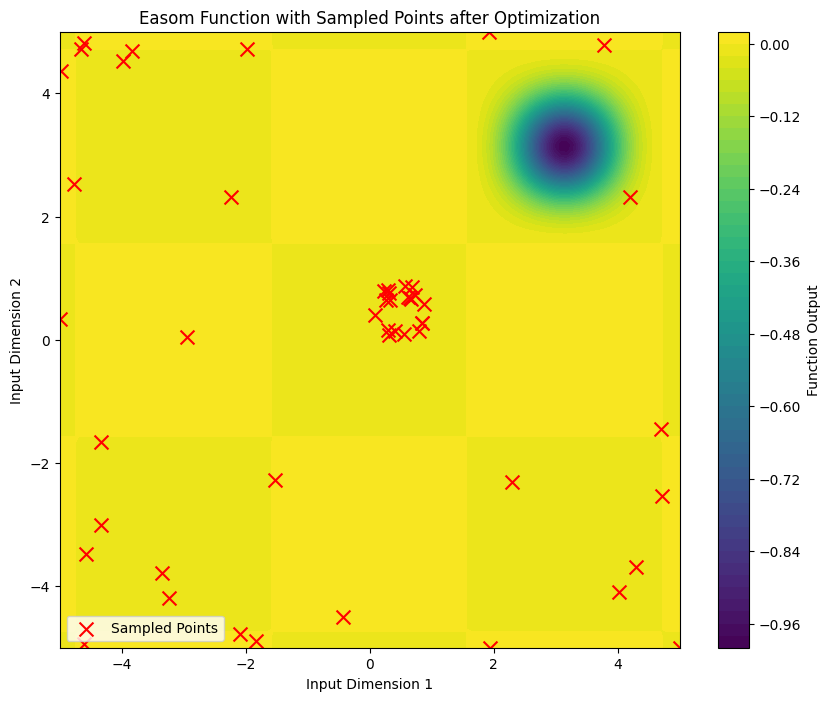

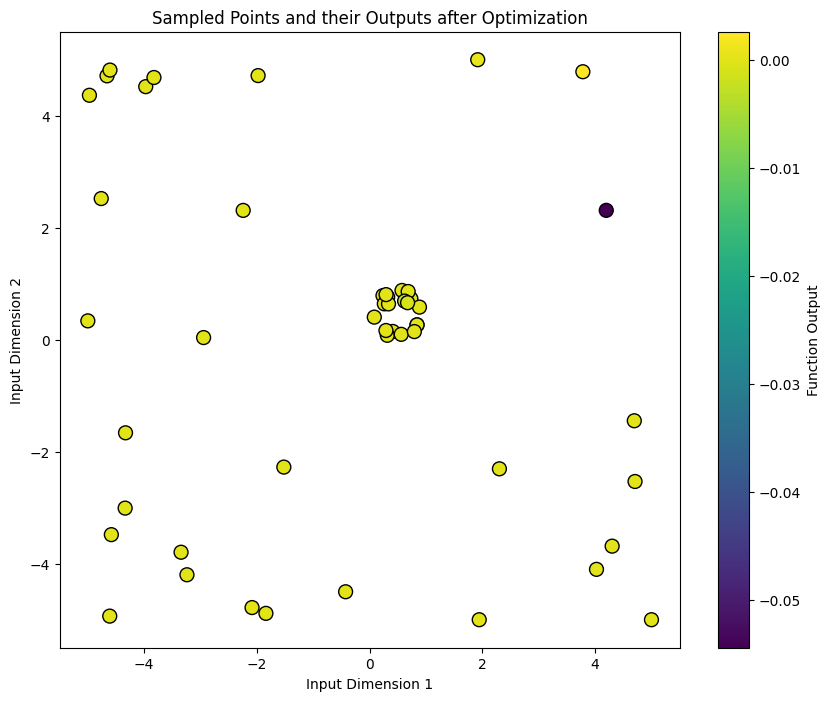

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize

# --- Define your actual Easom Function ---
def easom_function(x):
    """
    Easom function: f(x)= -cos(x1) cos(x2) exp(-(x1- π)2 – (x2- π)2)
    This function takes a 2-element numpy array [x1, x2] as input
    and returns a single float output.
    """
    x1, x2 = x[0], x[1]
    return -np.cos(x1) * np.cos(x2) * np.exp(-((x1 - np.pi)**2 + (x2 - np.pi)**2))

# --- Bayesian Optimization Components ---

# Define the Expected Improvement acquisition function (modified for maximization)
def expected_improvement(x, gp, current_best):
    """
    Calculates the Expected Improvement at a given point x for maximization.

    Args:
        x: Point to evaluate.
        gp: Gaussian Process model.
        current_best: Current best function value (maximum).

    Returns:
        Expected Improvement at x.
    """
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)  # Reshape for single-point prediction
    if sigma < 1e-10:  # Use a small tolerance for sigma near zero
        return 0.0
    improvement = mu - current_best
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# Define a function to optimize the acquisition function (for maximization)
def optimize_acquisition_function(acquisition_function, gp, current_best, bounds):
    """
    Optimizes the acquisition function to find the next input (maximizing EI).

    Args:
        acquisition_function: The acquisition function to optimize (EI).
        gp: Gaussian Process model.
        current_best: Current best function value (maximum).
        bounds: Bounds for the search space.

    Returns:
        The next input point.
    """
    # Define a function to minimize (negative of acquisition function)
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp, current_best)

    # Use scipy.optimize.minimize with multiple restarts for robustness
    num_restarts = 10
    best_x = None
    best_acquisition_value = np.inf # Initialize with a large value for minimization

    for _ in range(num_restarts):
        # Start minimization from random points within the bounds
        initial_guess = np.random.uniform(bounds[:, 0], bounds[:, 1])
        result = minimize(neg_acquisition_function, x0=initial_guess, bounds=bounds)
        if result.fun < best_acquisition_value:
            best_acquisition_value = result.fun
            best_x = result.x

    # Return the best found point or a random guess if optimization completely failed
    return best_x if best_x is not None and result.success else np.random.uniform(bounds[:, 0], bounds[:, 1])


# --- Bayesian Optimization Loop ---

# Define bounds for the search space (adjust as needed for your problem)
# The Easom function's global minimum is at (pi, pi), but you are
# looking for contamination sources in a square area, likely within
# a defined range. Let's assume a range, for example, -5 to 5 for both dimensions.
bounds = np.array([[-5, 5], [-5, 5]])

# Load or define initial data points
try:
    initial_inputs = np.load('/content/updated_inputs.npy')
    initial_outputs = np.load('/content/updated_outputs.npy')
    print("Loaded initial data from files.")
except FileNotFoundError:
    # Or define some initial points within the chosen bounds if the files don't exist
    initial_inputs = np.array([[0.1, 0.1], [3.0, 3.0], [-3.0, -3.0]]) # Example initial points
    initial_outputs = np.array([easom_function(x) for x in initial_inputs])
    print("Files not found, using initial defined data.")


# Create a Gaussian Process model
# You might need to tune the kernel parameters based on the function's behavior
kernel = 1.0 * RBF(length_scale=1.0) + Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)

# Fit the model to the initial data
gp.fit(initial_inputs, initial_outputs)

# Bayesian Optimization loop
num_iterations = 30  # Adjust as needed
current_best = np.max(initial_outputs)  # Initialize current best as the maximum output

print(f"Starting Bayesian Optimization for {num_iterations} iterations...")

for i in range(num_iterations):
    # Optimize acquisition function to find next input (maximizing EI)
    next_input = optimize_acquisition_function(expected_improvement, gp, current_best, bounds)

    # Query the function at the next input
    next_output = easom_function(next_input)

    # Update the GP model with the new data
    initial_inputs = np.vstack([initial_inputs, next_input])
    initial_outputs = np.append(initial_outputs, next_output)
    gp.fit(initial_inputs, initial_outputs)

    # Update current best (find the maximum output)
    current_best = np.max(initial_outputs)

    print(f"Iteration {i+1}: Next Query = {next_input}, Output = {next_output}, Current Best = {current_best}")


# Print the final optimized inputs and outputs
print("\n--- Optimization Complete ---")
print("Optimized Inputs:", initial_inputs)
print("Optimized Outputs:", initial_outputs)

# To find the points corresponding to the two highest peaks, you can sort the outputs
sorted_indices = np.argsort(initial_outputs)[::-1] # Get indices of outputs sorted in descending order
top_n = 5  # Adjust to see more or fewer top points
print(f"\nTop {top_n} Outputs and Corresponding Inputs (Potential Contamination Sources):")
for i in range(min(top_n, len(initial_outputs))):
    idx = sorted_indices[i]
    print(f"Output: {initial_outputs[idx]:.4e}, Input: {initial_inputs[idx]}")


# --- Visualization of Results ---

# Create a grid of points for visualization within the optimization bounds
x = np.linspace(bounds[0, 0], bounds[0, 1], 100)
y = np.linspace(bounds[1, 0], bounds[1, 1], 100)
X, Y = np.meshgrid(x, y)

# Calculate Z by applying the Easom function to the grid points
points = np.vstack([X.ravel(), Y.ravel()]).T
Z = np.array([easom_function(point) for point in points]).reshape(X.shape)

# Create the plot
plt.figure(figsize=(10, 8))
plt.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.colorbar(label='Function Output')
plt.scatter(initial_inputs[:, 0], initial_inputs[:, 1], c='red', marker='x', s=100, edgecolors='black', label='Sampled Points')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Easom Function with Sampled Points after Optimization')
plt.legend()
plt.show()

# Scatter plot of sampled points and their outputs
plt.figure(figsize=(10, 8))
plt.scatter(initial_inputs[:, 0], initial_inputs[:, 1], c=initial_outputs, cmap='viridis', s=100, edgecolors='black')
plt.colorbar(label='Function Output')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Sampled Points and their Outputs after Optimization')
plt.show()

In [ ]:
import numpy as np

# Load the updated data from the files
try:
    updated_inputs = np.load('/content/updated_inputs.npy')
    updated_outputs = np.load('/content/updated_outputs.npy')
    print("Loaded updated data from files.")

    # Find the indices of the outputs sorted in descending order
    sorted_indices = np.argsort(updated_outputs)[::-1]

    # Define how many potential sources you want to see (e.g., the top 2 or 3)
    num_potential_sources = 3  # You can adjust this number

    print(f"\nCurrent Estimated Potential Contamination Sources (Top {num_potential_sources}):")

    # Print the top outputs and their corresponding inputs
    for i in range(min(num_potential_sources, len(updated_outputs))):
        idx = sorted_indices[i]
        print(f"Location (Input): {updated_inputs[idx]}, Reading (Output): {updated_outputs[idx]:.4e}")

except FileNotFoundError:
    print("Updated data files not found. Please run the Bayesian Optimization code first to generate data.")
except Exception as e:
    print(f"An error occurred while loading or processing data: {e}")

Loaded updated data from files.

Current Estimated Potential Contamination Sources (Top 3):
Location (Input): [0.73102363 0.73299988], Reading (Output): 7.7109e-16
Location (Input): [0.334402 0.639738], Reading (Output): 3.0645e-39
Location (Input): [0.68341817 0.86105746], Reading (Output): 2.5350e-40


In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize

# --- Define your actual Easom Function ---
# (You'll still need this definition, even if you're just calculating the next query)
def easom_function(x):
    """
    Easom function: f(x)= -cos(x1) cos(x2) exp(-(x1- π)2 – (x2- π)2)
    This function takes a 2-element numpy array [x1, x2] as input
    and returns a single float output.
    """
    x1, x2 = x[0], x[1]
    return -np.cos(x1) * np.cos(x2) * np.exp(-((x1 - np.pi)**2 + (x2 - np.pi)**2))


# --- Bayesian Optimization Components ---

# Define the Expected Improvement acquisition function (modified for maximization)
def expected_improvement(x, gp, current_best):
    """
    Calculates the Expected Improvement at a given point x for maximization.
    """
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    if sigma < 1e-10:
        return 0.0
    improvement = mu - current_best
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# Define a function to optimize the acquisition function (for maximization)
def optimize_acquisition_function(acquisition_function, gp, current_best, bounds):
    """
    Optimizes the acquisition function to find the next input (maximizing EI).
    """
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp, current_best)

    num_restarts = 10
    best_x = None
    best_acquisition_value = np.inf

    for _ in range(num_restarts):
        initial_guess = np.random.uniform(bounds[:, 0], bounds[:, 1])
        result = minimize(neg_acquisition_function, x0=initial_guess, bounds=bounds)
        if result.fun < best_acquisition_value:
            best_acquisition_value = result.fun
            best_x = result.x

    return best_x if best_x is not None and result.success else np.random.uniform(bounds[:, 0], bounds[:, 1])


# --- Calculate the Next Query ---

# Define bounds for the search space (make sure these match your problem's bounds)
# Example: bounds = np.array([[-5, 5], [-5, 5]])
# **IMPORTANT: Set these bounds to match the square area you are searching in.**
bounds = np.array([[0, 1], [0, 1]]) # Example bounds, adjust as needed

# Load the updated data from the files
try:
    updated_inputs = np.load('/content/updated_inputs.npy')
    updated_outputs = np.load('/content/updated_outputs.npy')
    print("Loaded updated data from files.")

    # Create and fit the Gaussian Process model on the updated data
    # Use the same kernel parameters as in your optimization loop
    kernel = 1.0 * RBF(length_scale=1.0) + Matern(length_scale=1.0, nu=2.5)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)
    gp.fit(updated_inputs, updated_outputs)

    # Get the current best output from the loaded data
    current_best = np.max(updated_outputs)

    # Optimize the acquisition function to find the next query point
    next_query = optimize_acquisition_function(expected_improvement, gp, current_best, bounds)

    print("\nNext Suggested Query Location:", next_query)

except FileNotFoundError:
    print("Updated data files not found. Please run the Bayesian Optimization code first to generate data.")
except Exception as e:
    print(f"An error occurred while calculating the next query: {e}")

Loaded updated data from files.


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(



Next Suggested Query Location: [0.38496351 0.03421473]


Loaded updated data from files.


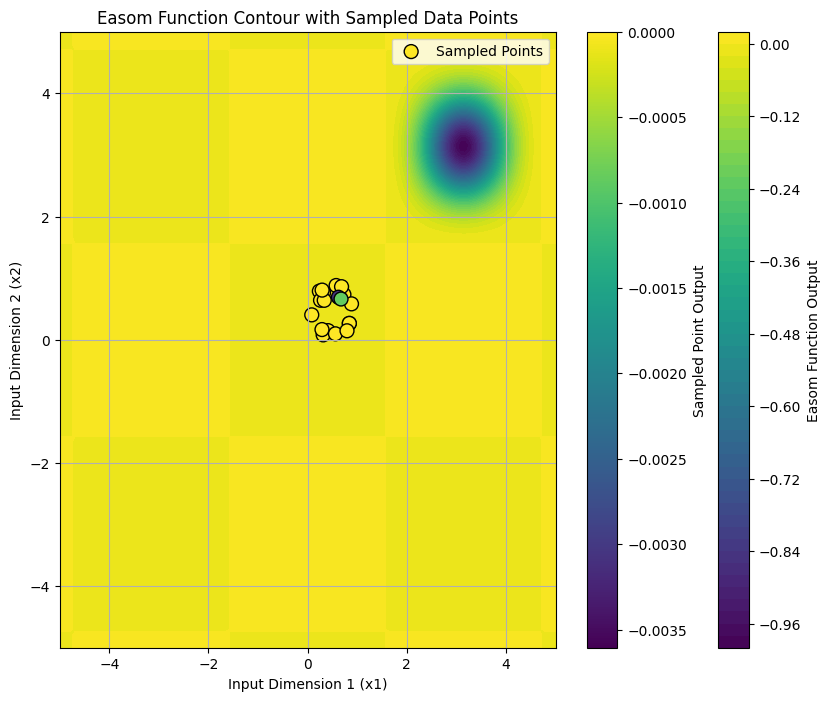

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Define your actual Easom Function ---
def easom_function(x):
    """
    Easom function: f(x)= -cos(x1) cos(x2) exp(-(x1- π)2 – (x2- π)2)
    This function takes a 2-element numpy array [x1, x2] as input
    and returns a single float output.
    """
    x1, x2 = x[0], x[1]
    return -np.cos(x1) * np.cos(x2) * np.exp(-((x1 - np.pi)**2 + (x2 - np.pi)**2))

# --- Load the updated data ---
try:
    updated_inputs = np.load('/content/updated_inputs.npy')
    updated_outputs = np.load('/content/updated_outputs.npy')
    print("Loaded updated data from files.")
except FileNotFoundError:
    print("Updated data files not found. Please run the Bayesian Optimization code first to generate data.")
    # You might want to exit or handle this case differently if the files are essential
    exit() # Exit the script if data is not found

# --- Define the plotting range ---
# Adjust these bounds to match the square area you are searching in.
plot_bounds = np.array([[-5, 5], [-5, 5]]) # Example bounds, adjust as needed

# --- Create a grid of points for visualization within the plotting range ---
x_plot = np.linspace(plot_bounds[0, 0], plot_bounds[0, 1], 100)
y_plot = np.linspace(plot_bounds[1, 0], plot_bounds[1, 1], 100)
X_plot, Y_plot = np.meshgrid(x_plot, y_plot)

# --- Calculate Z by applying the Easom function to the grid points ---
# Reshape X_plot and Y_plot to a list of (x, y) points
points_plot = np.vstack([X_plot.ravel(), Y_plot.ravel()]).T
# Apply the Easom function to each point using list comprehension
Z_plot = np.array([easom_function(point) for point in points_plot]).reshape(X_plot.shape)

# --- Create the plot ---
plt.figure(figsize=(10, 8))  # Adjust figure size as needed

# Plot the contour of the Easom function
contour = plt.contourf(X_plot, Y_plot, Z_plot, levels=50, cmap='viridis')
plt.colorbar(contour, label='Easom Function Output')  # Add a colorbar

# Plot your sampled points on top
scatter = plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c=updated_outputs, cmap='viridis', marker='o', s=100, edgecolors='black', label='Sampled Points')
plt.colorbar(scatter, label='Sampled Point Output') # Add a colorbar for the sampled points

# Add labels and title
plt.xlabel('Input Dimension 1 (x1)')
plt.ylabel('Input Dimension 2 (x2)')
plt.title('Easom Function Contour with Sampled Data Points')
plt.legend()
plt.grid(True) # Add a grid for better readability
plt.show()

In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point to add
new_input = np.array([0.384963, 0.034214])
new_output = np.float64(-8.043693501905595e-107)

# Add new data point if it is not already present
if not any(np.array_equal(new_input, existing_input) for existing_input in updated_inputs):
    updated_inputs = np.vstack([updated_inputs, new_input])
    updated_outputs = np.append(updated_outputs, new_output)

# Save the updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated input and output files created successfully!")

Updated input and output files created successfully!


In [ ]:
import numpy as np

# Load the data from the files
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.62       0.69      ]
 [0.236354   0.788452  ]
 [0.840353   0.264731  ]
 [0.260138   0.640907  ]
 [0.289375   0.164924  ]
 [0.560479   0.095948  ]
 [0.334402   0.639738  ]
 [0.793274   0.145087  ]
 [0.673      0.661     ]
 [0.291687   0.805427  ]
 [0.384963   0.034214  ]]

Updated Outputs:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -3.08568565e-003 -9.00536660e-119
  3.34043477e-124 -2.23322471e-052 -5.07830044e-059  5.91888607e-088
  3.06452636e-039 -2.89242162e-151 -8.69448797e-004  2.22822772e-101
 -8.04369350e-107]


In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the Expected Improvement acquisition function
def expected_improvement(x, gp, current_best):
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    if sigma == 0.0:
        return 0.0
    improvement = mu - current_best
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# Define a function to optimize the acquisition function
def optimize_acquisition_function(acquisition_function, gp, current_best, bounds):
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp, current_best)
    result = minimize(neg_acquisition_function, x0=np.random.uniform(bounds[:, 0], bounds[:, 1]), bounds=bounds)
    return result.x

# Define bounds for the search space (assuming 0 to 1 based on your earlier code)
bounds = np.array([[0, 1], [0, 1]])

# Create and train the Gaussian Process model on the updated data
kernel = 1.0 * RBF(1.0) + Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)
gp.fit(updated_inputs, updated_outputs)

# Determine the current best output
current_best = np.min(updated_outputs)

# Optimize the acquisition function to find the next query point
next_query = optimize_acquisition_function(expected_improvement, gp, current_best, bounds)

print("Next Query:", next_query)

Next Query: [0.24921178 0.36604526]


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.optimize import minimize

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the Easom function (assuming you still need this for testing or visualization)
def easom_function(x):
    return -np.cos(x[0]) * np.cos(x[1]) * np.exp(-((x[0] - np.pi)**2 + (x[1] - np.pi)**2))

# Define the Expected Improvement acquisition function
def expected_improvement(x, gp, current_best):
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    if sigma == 0.0:
        return 0.0
    improvement = mu - current_best
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# Define a function to optimize the acquisition function
def optimize_acquisition_function(acquisition_function, gp, current_best, bounds):
    def neg_acquisition_function(x):
        return -acquisition_function(x, gp, current_best)
    result = minimize(neg_acquisition_function, x0=np.random.uniform(bounds[:, 0], bounds[:, 1]), bounds=bounds)
    return result.x

# Define bounds for the search space (assuming 0 to 1 based on your earlier code)
bounds = np.array([[0, 1], [0, 1]])

# Create and train the Gaussian Process model on the updated data
# Increased upper bound for the length_scale of the Matern kernel
kernel = 1.0 * RBF(1.0) + Matern(length_scale=1.0, length_scale_bounds=(1e-5, 1e6), nu=2.5) # Increased upper bound
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5)
gp.fit(updated_inputs, updated_outputs)

# Determine the current best output
current_best = np.min(updated_outputs)

# Optimize the acquisition function to find the next query point
next_query = optimize_acquisition_function(expected_improvement, gp, current_best, bounds)

print("Next Query:", next_query)

Next Query: [0.77895208 0.15676684]


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 1000000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
import numpy as np

# Load the data from the files
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.62       0.69      ]
 [0.236354   0.788452  ]
 [0.840353   0.264731  ]
 [0.260138   0.640907  ]
 [0.289375   0.164924  ]
 [0.560479   0.095948  ]
 [0.334402   0.639738  ]
 [0.793274   0.145087  ]
 [0.673      0.661     ]
 [0.291687   0.805427  ]
 [0.384963   0.034214  ]]

Updated Outputs:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -3.08568565e-003 -9.00536660e-119
  3.34043477e-124 -2.23322471e-052 -5.07830044e-059  5.91888607e-088
  3.06452636e-039 -2.89242162e-151 -8.69448797e-004  2.22822772e-101
 -8.04369350e-107]


In [ ]:
import numpy as np

# Load the updated data (assuming you have already loaded it)
# updated_inputs = np.load('/content/updated_inputs.npy')
# updated_outputs = np.load('/content/updated_outputs.npy')

# Filter out points with output very close to zero
non_zero_indices = np.where(np.abs(updated_outputs) > 1e-9)[0] # Adjust tolerance if needed
non_zero_inputs = updated_inputs[non_zero_indices]
non_zero_outputs = updated_outputs[non_zero_indices]

# Sort the non-zero points by output value (most negative first)
sorted_indices = np.argsort(non_zero_outputs)
sorted_inputs = non_zero_inputs[sorted_indices]
sorted_outputs = non_zero_outputs[sorted_indices]

# Print the sorted non-zero points (the "peaks")
print("Non-zero points sorted by output (most negative first - peaks):")
for i in range(len(sorted_inputs)):
    print(f"Input: {sorted_inputs[i]}, Output: {sorted_outputs[i]}")

# You can print a specific number of top peaks, e.g., the top 2
num_peaks_to_print = 2
print(f"\nTop {num_peaks_to_print} best points (most negative outputs):")
for i in range(min(num_peaks_to_print, len(sorted_inputs))):
    print(f"Input: {sorted_inputs[i]}, Output: {sorted_outputs[i]}")

Non-zero points sorted by output (most negative first - peaks):
Input: [0.65011406 0.68152635], Output: -0.0036060626443634764
Input: [0.62 0.69], Output: -0.003085685650307045
Input: [0.673 0.661], Output: -0.0008694487971110799

Top 2 best points (most negative outputs):
Input: [0.65011406 0.68152635], Output: -0.0036060626443634764
Input: [0.62 0.69], Output: -0.003085685650307045
